# Mass Model — Final: 2×Layers + OneCycleLR + b=32

Flow $x$: `log_prot`  
Conditioning: `[log_age_myr, mass_msun, mass_msun_err_lo, mass_msun_err_hi]`

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt

from training.constants import LOGA_GRID
from training.data      import load_training, make_holdout_split
from training.kfold     import run_kfold
from training.plots     import set_paper_style, plot_posteriors_by_age, plot_praesepe_density, plot_fixed_mass_heatmap, plot_fixed_feature_heatmap
from training.report    import training_report, kfold_report, prot_space_report, coverage_report

set_paper_style()

## 1. Load data

In [2]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=False)
train_val_df, test_df = make_holdout_split(df, test_frac=0.10)

print(f'Total stars     : {len(df)}')
print(f'Train/val pool  : {len(train_val_df)}  ({len(train_val_df)/len(df)*100:.1f}%)')
print(f'Test holdout    : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)')

Total stars     : 6128
Train/val pool  : 5515  (90.0%)
Test holdout    : 613  (10.0%)


## 2. Config

In [3]:
OBS_COL         = 'log_prot'
COND_COLS       = ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']
N_FOLDS         = 5
TOTAL_STEPS     = 10000
N_SAMPLES       = 10
HIDDEN_FEATURES = (64, 64, 64, 64)
BATCH_SIZE      = 32

print(f'Architecture    : {HIDDEN_FEATURES}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Total steps     : {TOTAL_STEPS}')
print(f'Scheduler       : OneCycleLR')
n_train_approx = int(len(train_val_df) * 0.8)
spe = max(1, n_train_approx // BATCH_SIZE)
print(f'~{spe} steps/epoch  ~{TOTAL_STEPS // spe} epochs')

Architecture    : (64, 64, 64, 64)
Batch size      : 32
Total steps     : 10000
Scheduler       : OneCycleLR
~137 steps/epoch  ~72 epochs


## 3. K-fold training

In [4]:
results_df, fold_flows, fold_scalers, train_curves, val_curves, test_lls, posteriors = run_kfold(
    df              = train_val_df,
    test_df         = test_df,
    obs_col         = OBS_COL,
    cond_cols       = COND_COLS,
    n_folds         = N_FOLDS,
    total_steps     = TOTAL_STEPS,
    batch_size      = BATCH_SIZE,
    n_samples       = N_SAMPLES,
    use_onecycle    = True,
    hidden_features = HIDDEN_FEATURES,
)


=== Fold 1 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.317340)
  test avg log-likelihood: -0.339447

=== Fold 2 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.344455)
  test avg log-likelihood: -0.325388

=== Fold 3 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.350086)
  test avg log-likelihood: -0.357185

=== Fold 4 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.355146)
  test avg log-likelihood: -0.348187

=== Fold 5 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.345974)
  test avg log-likelihood: -0.340299

=== Mean test avg log-likelihood across folds: -0.342101 ===


## 4. Training curves

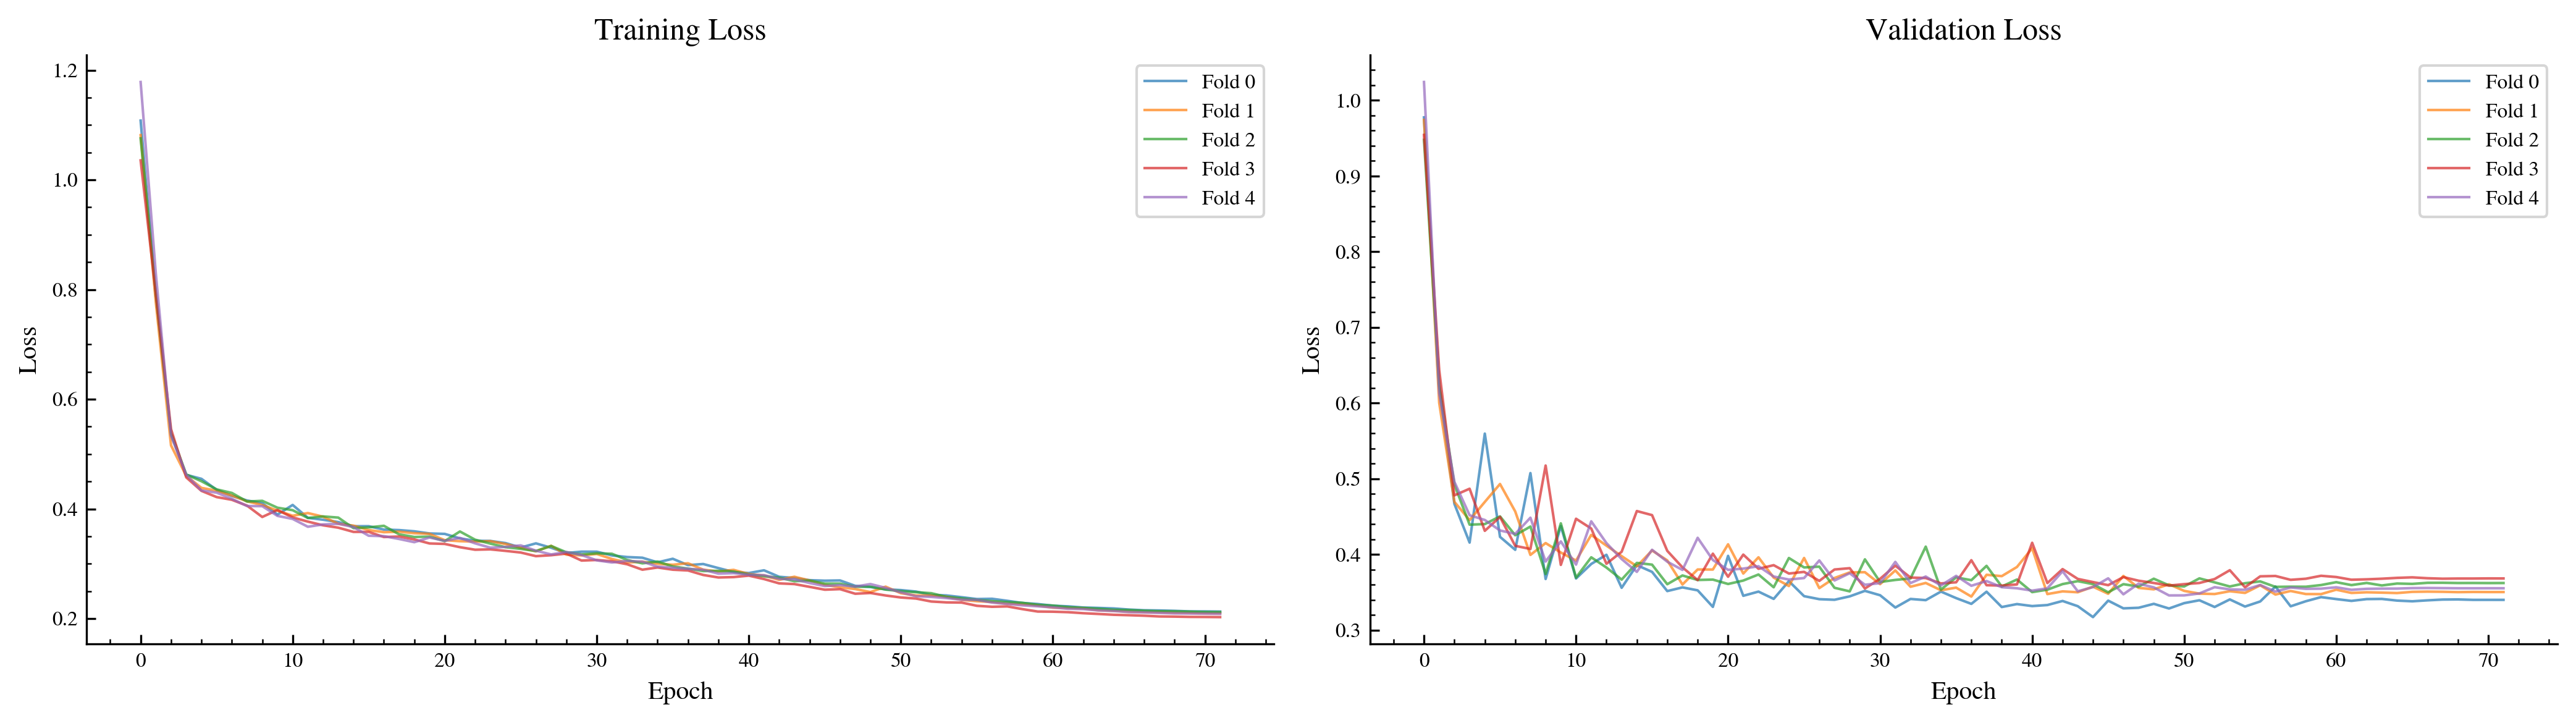

In [5]:
training_report(train_curves, val_curves)

## 5. Residual diagnostics

/Users/alanxia/Documents/GitHub/cf_xmatch/training/notebooks/../../training/plots.py:287: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.scatter(xvals, resid, **_kw_scat)


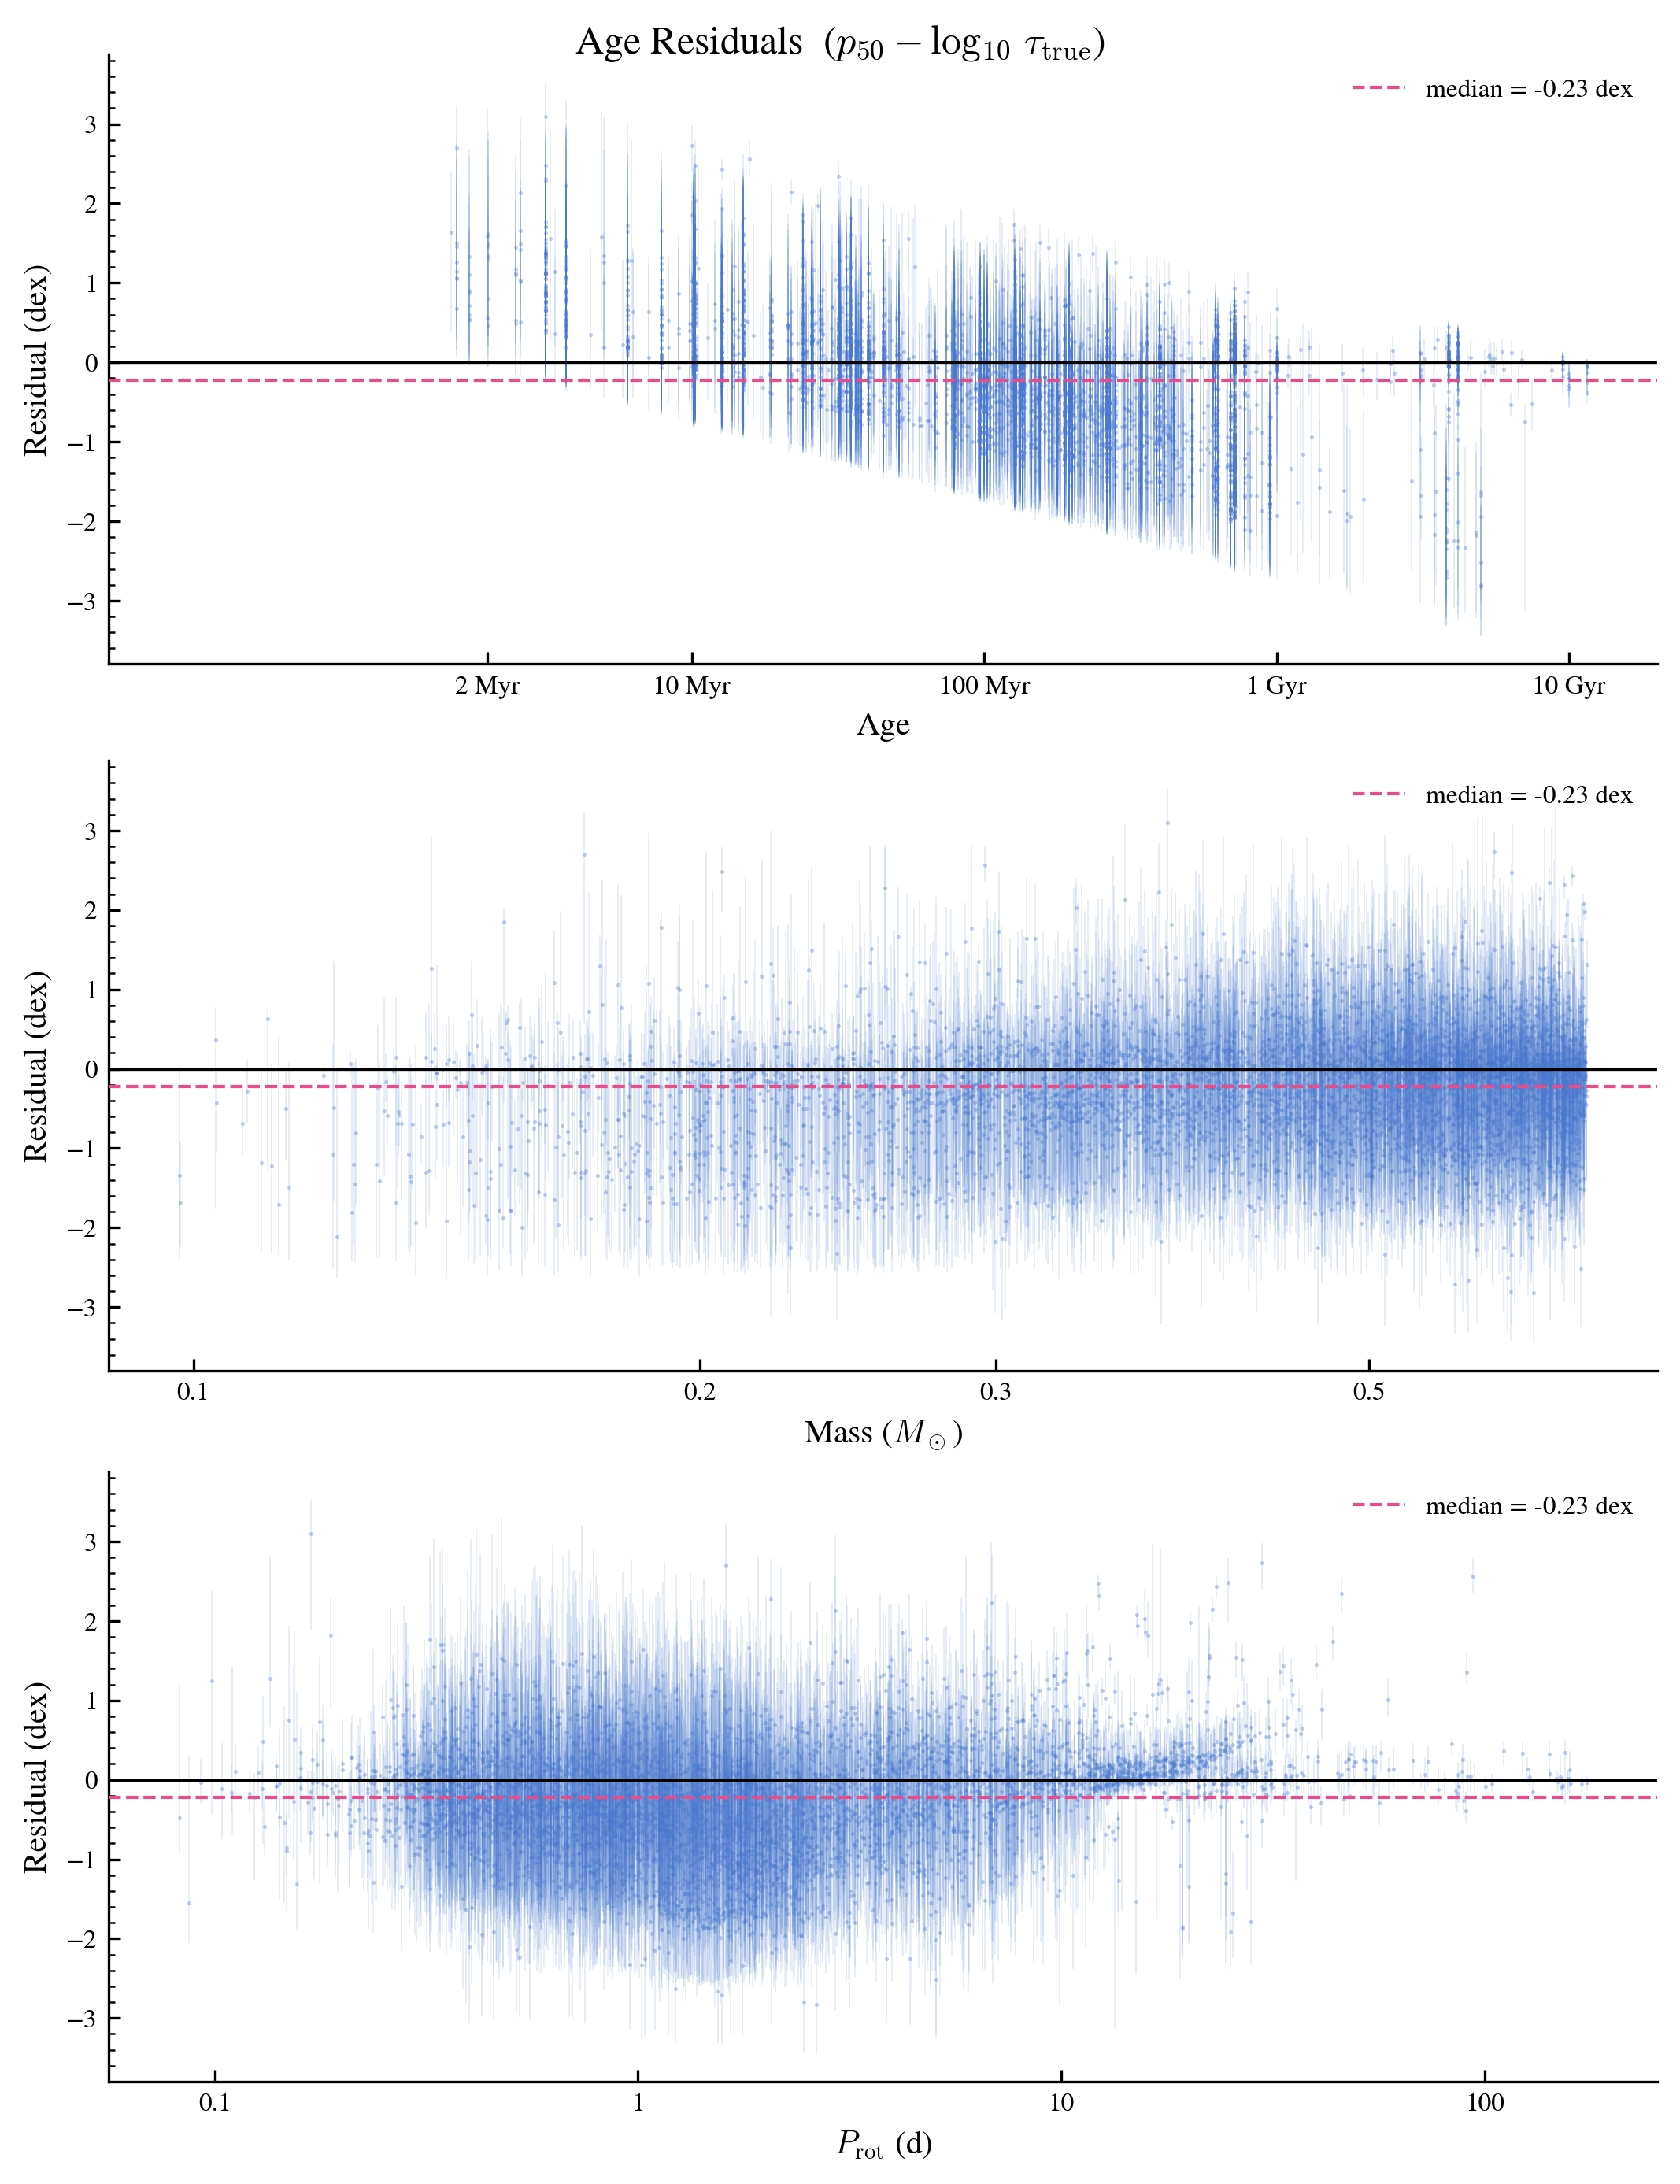

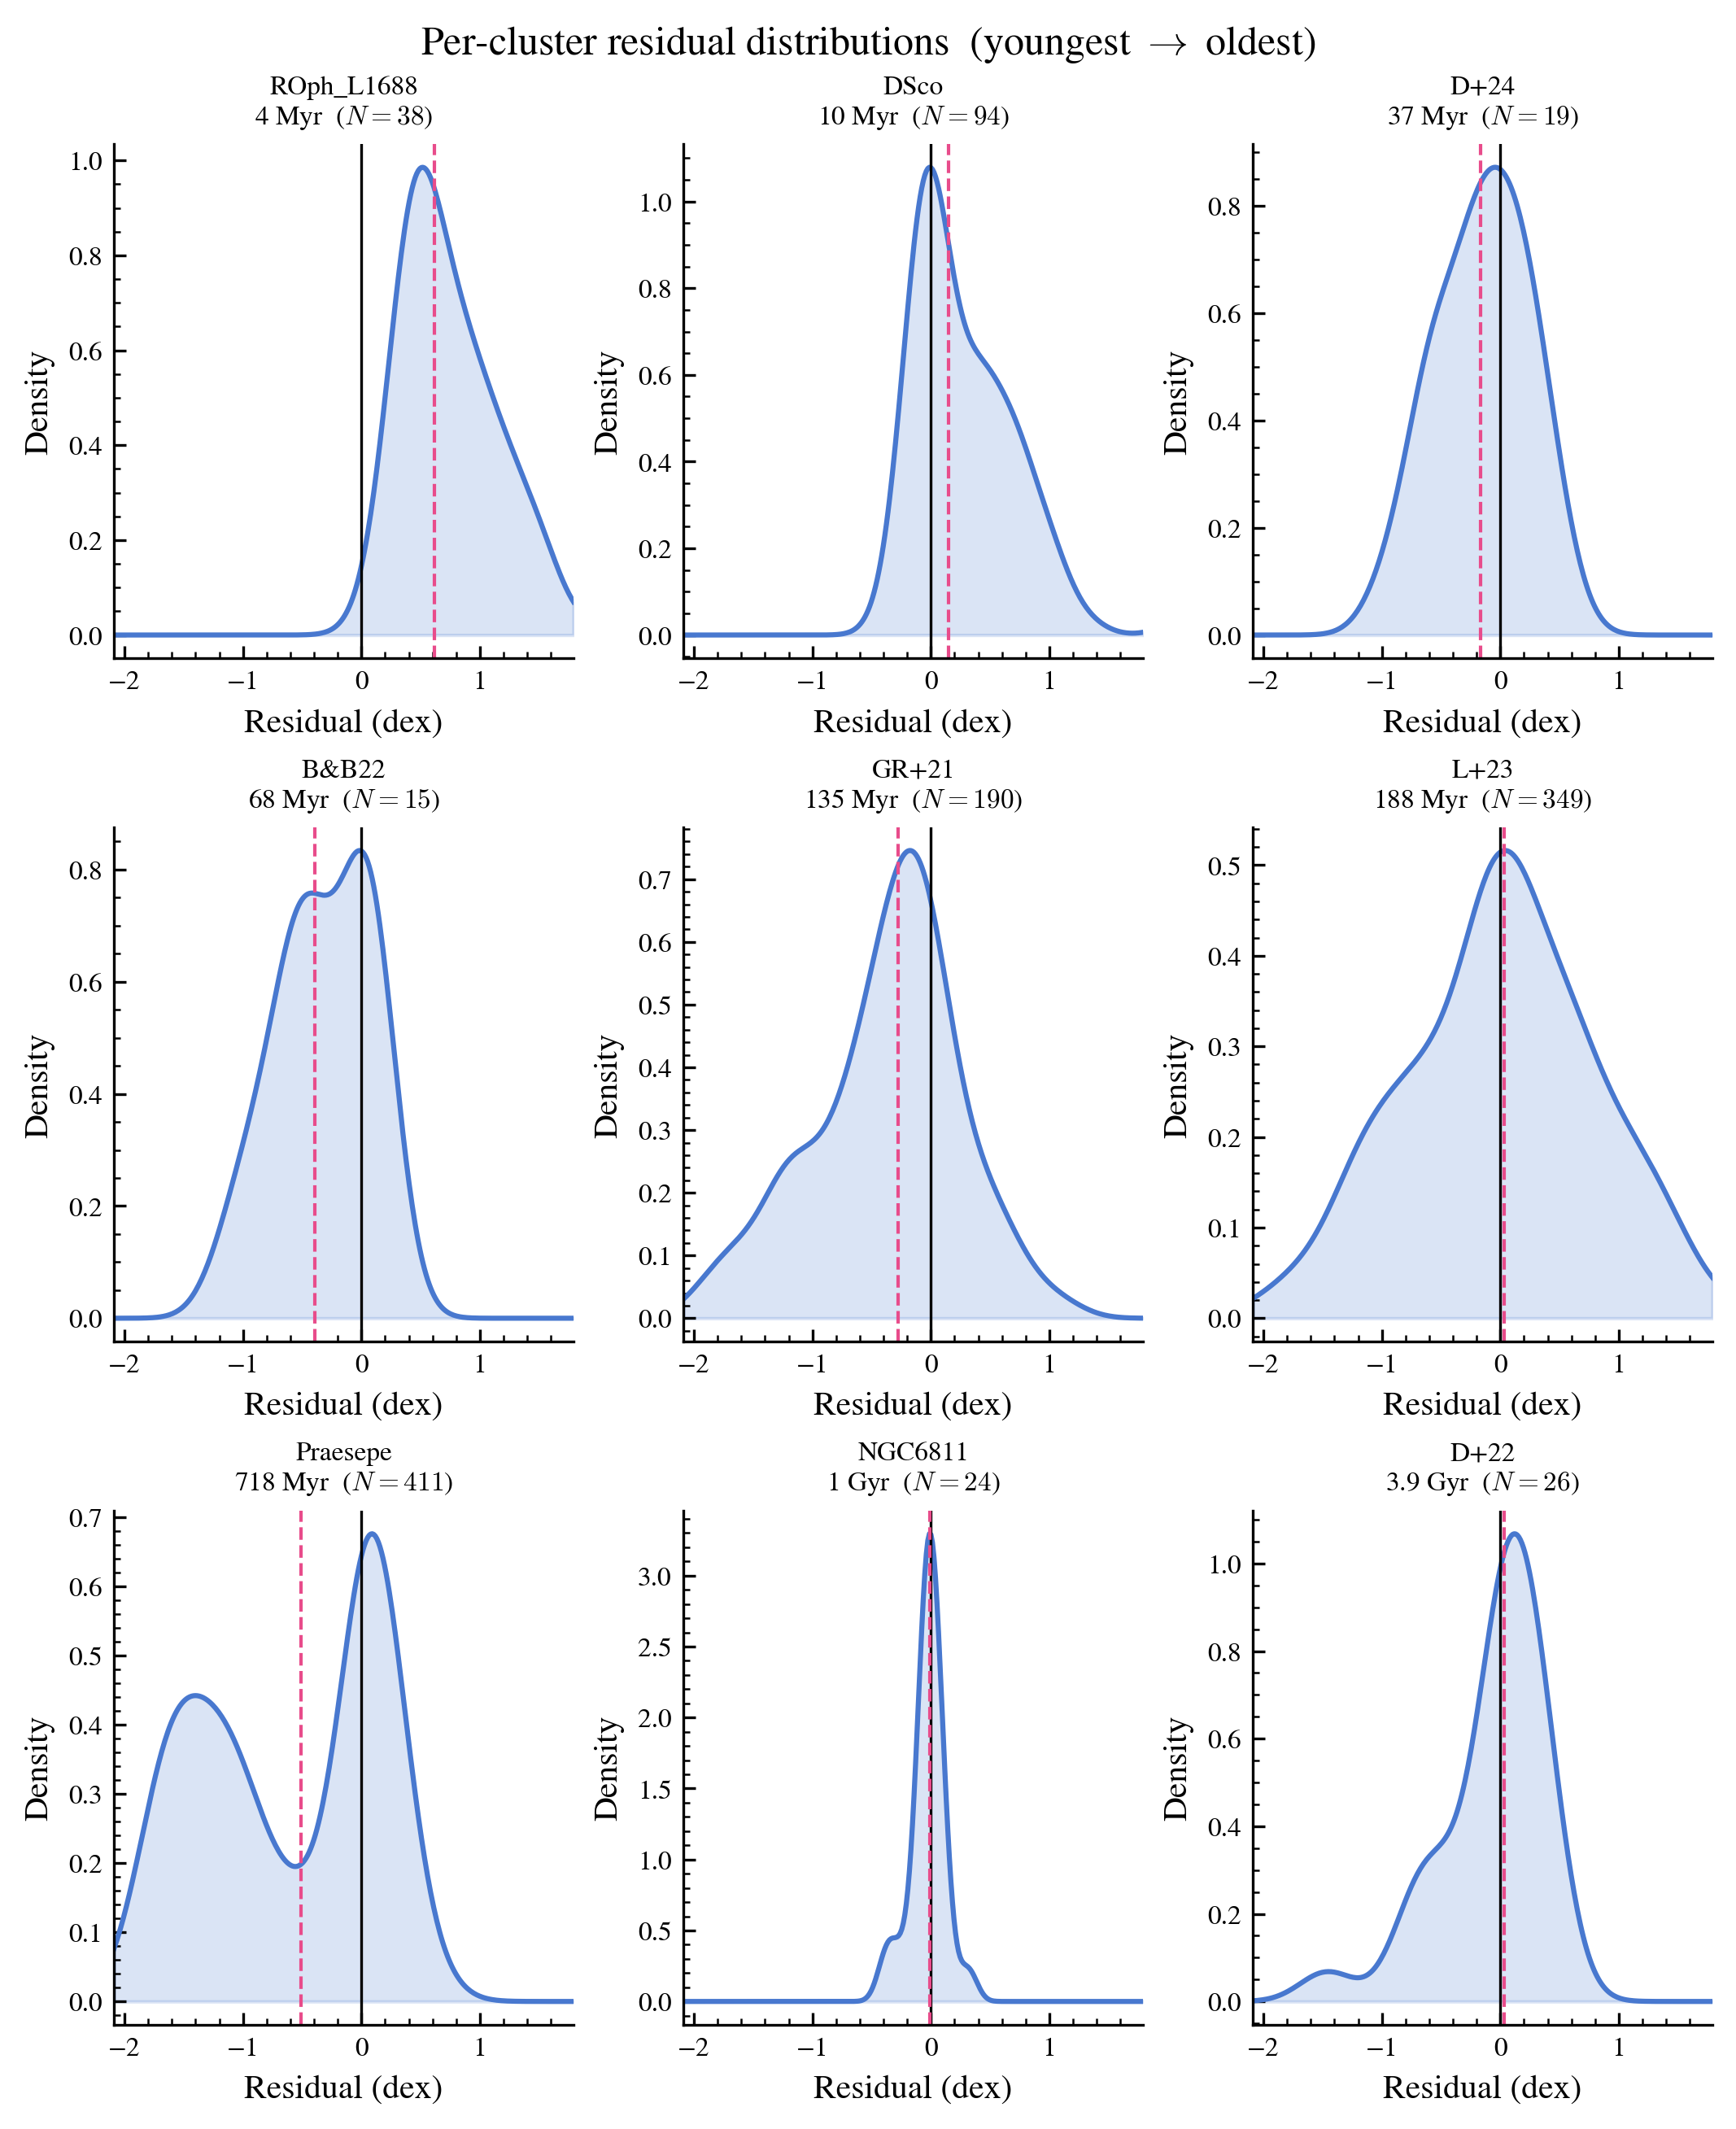

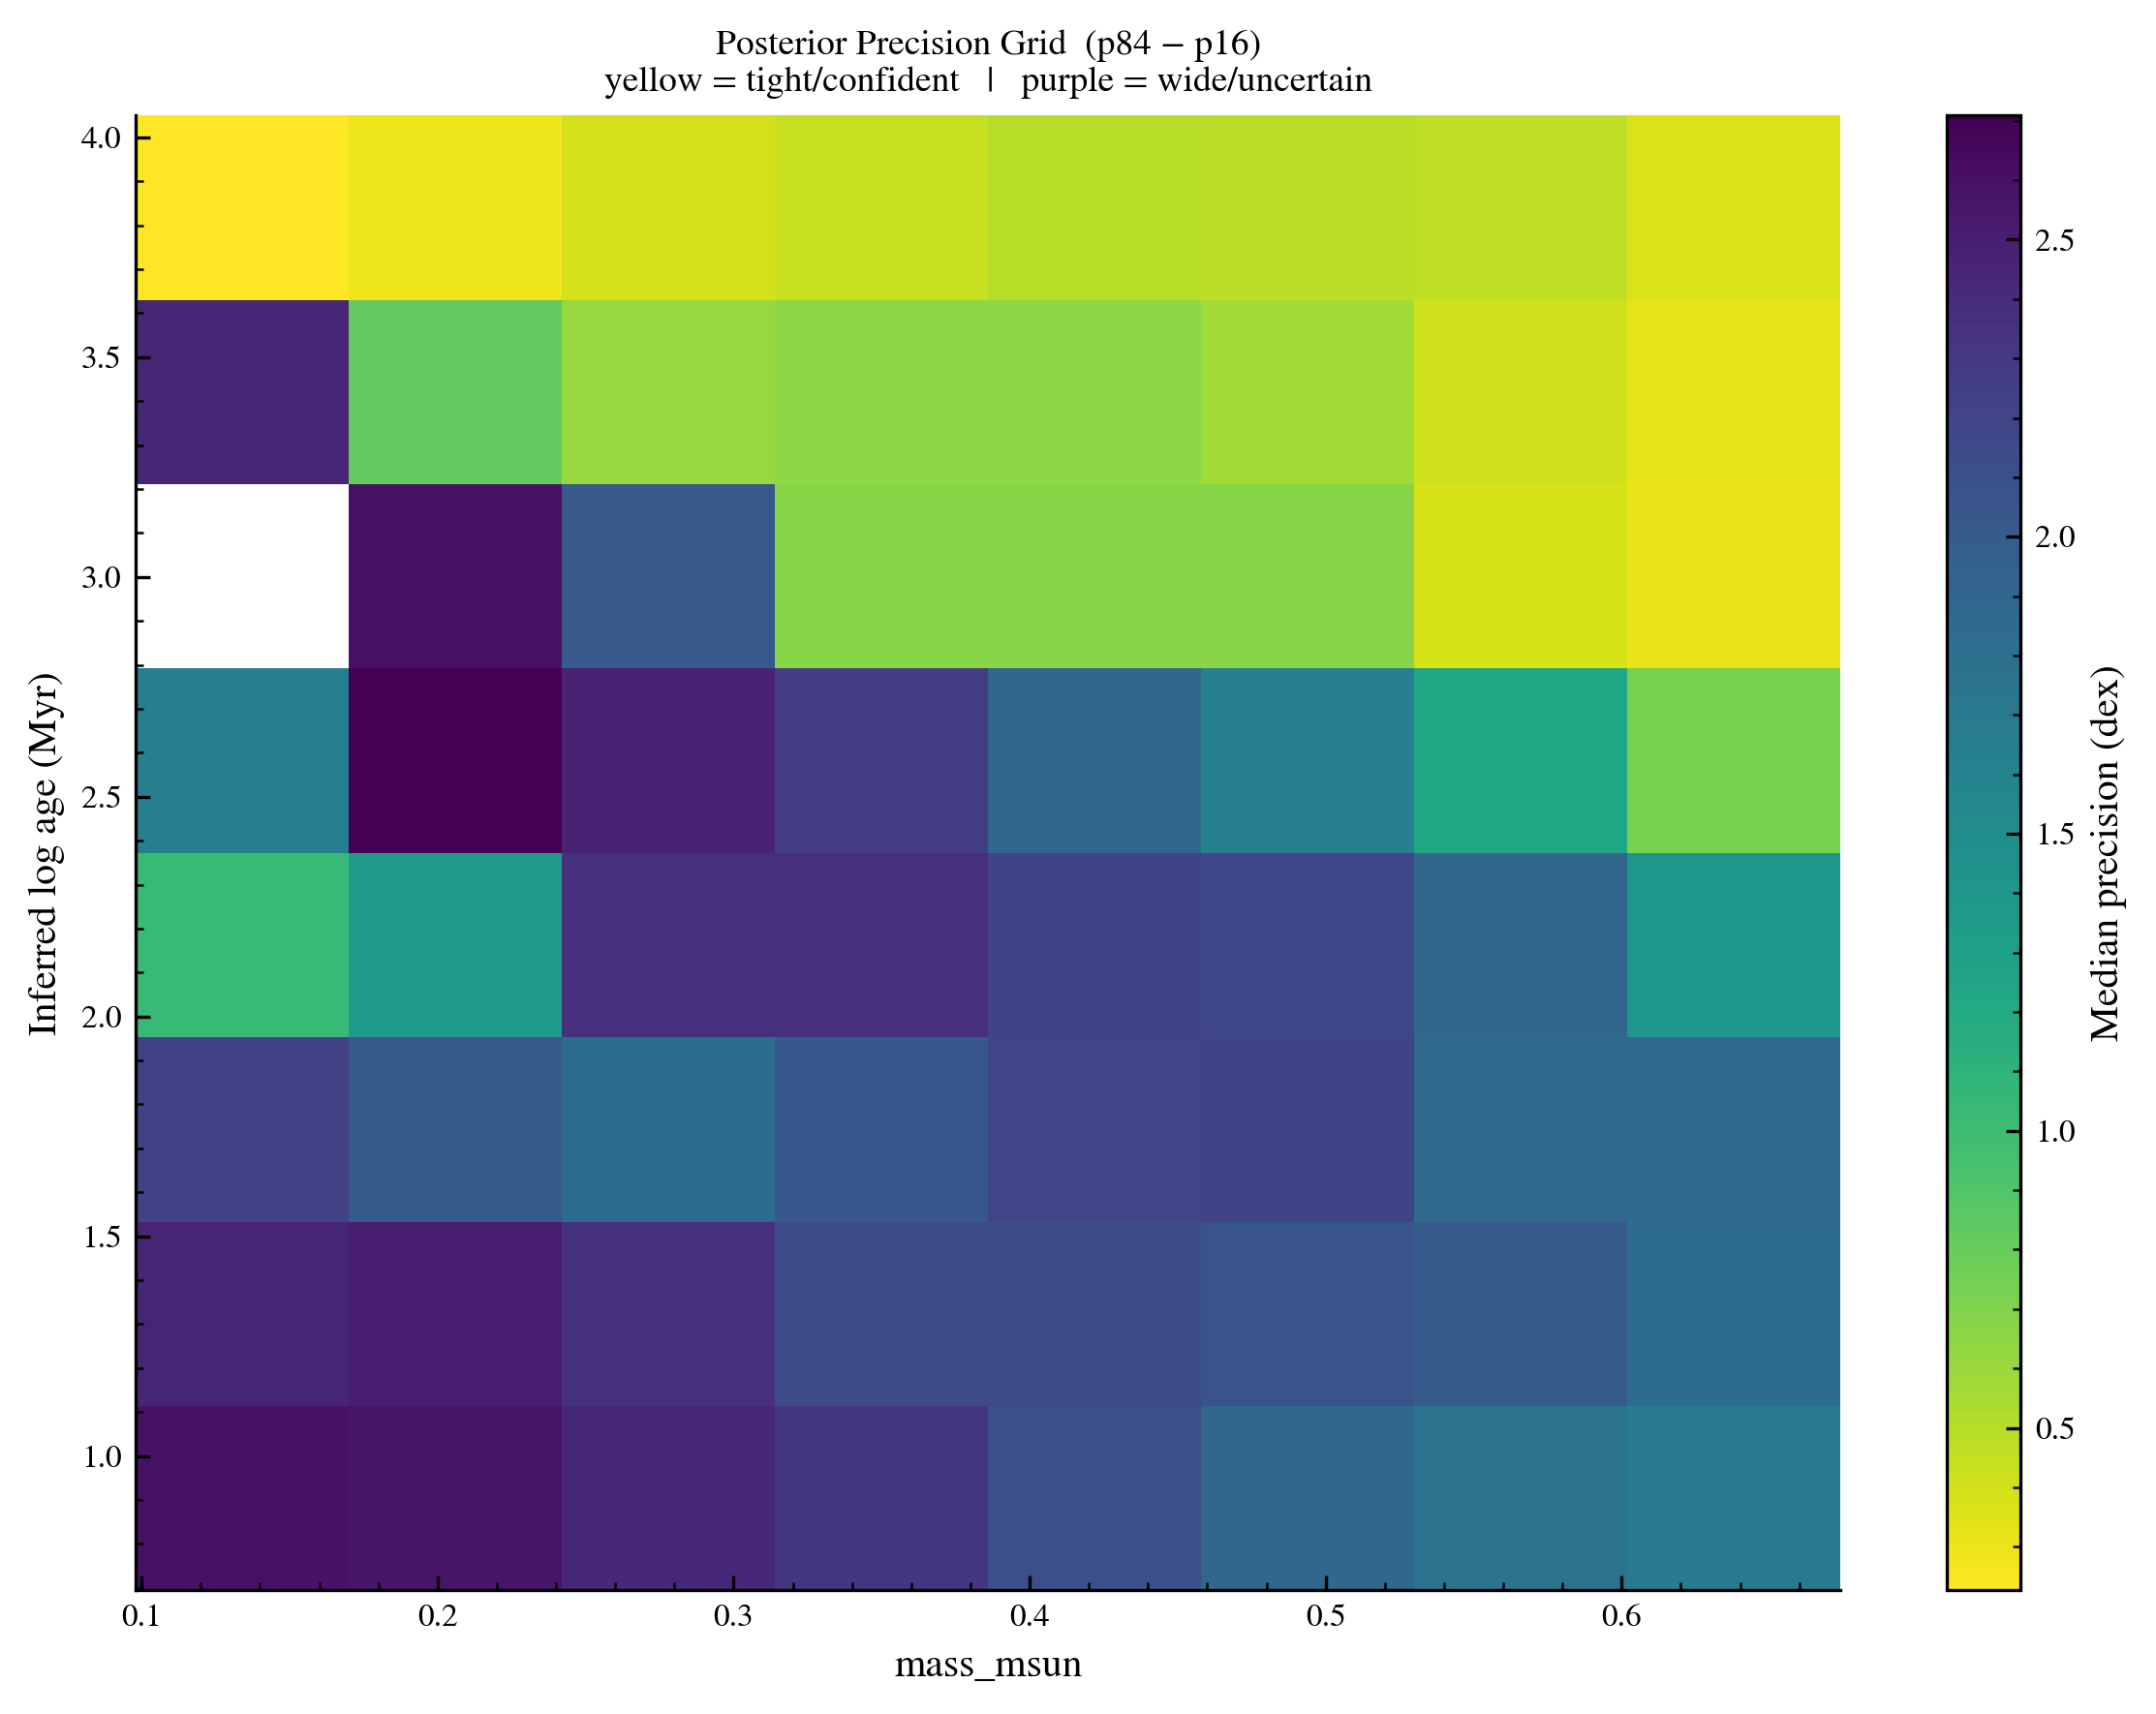

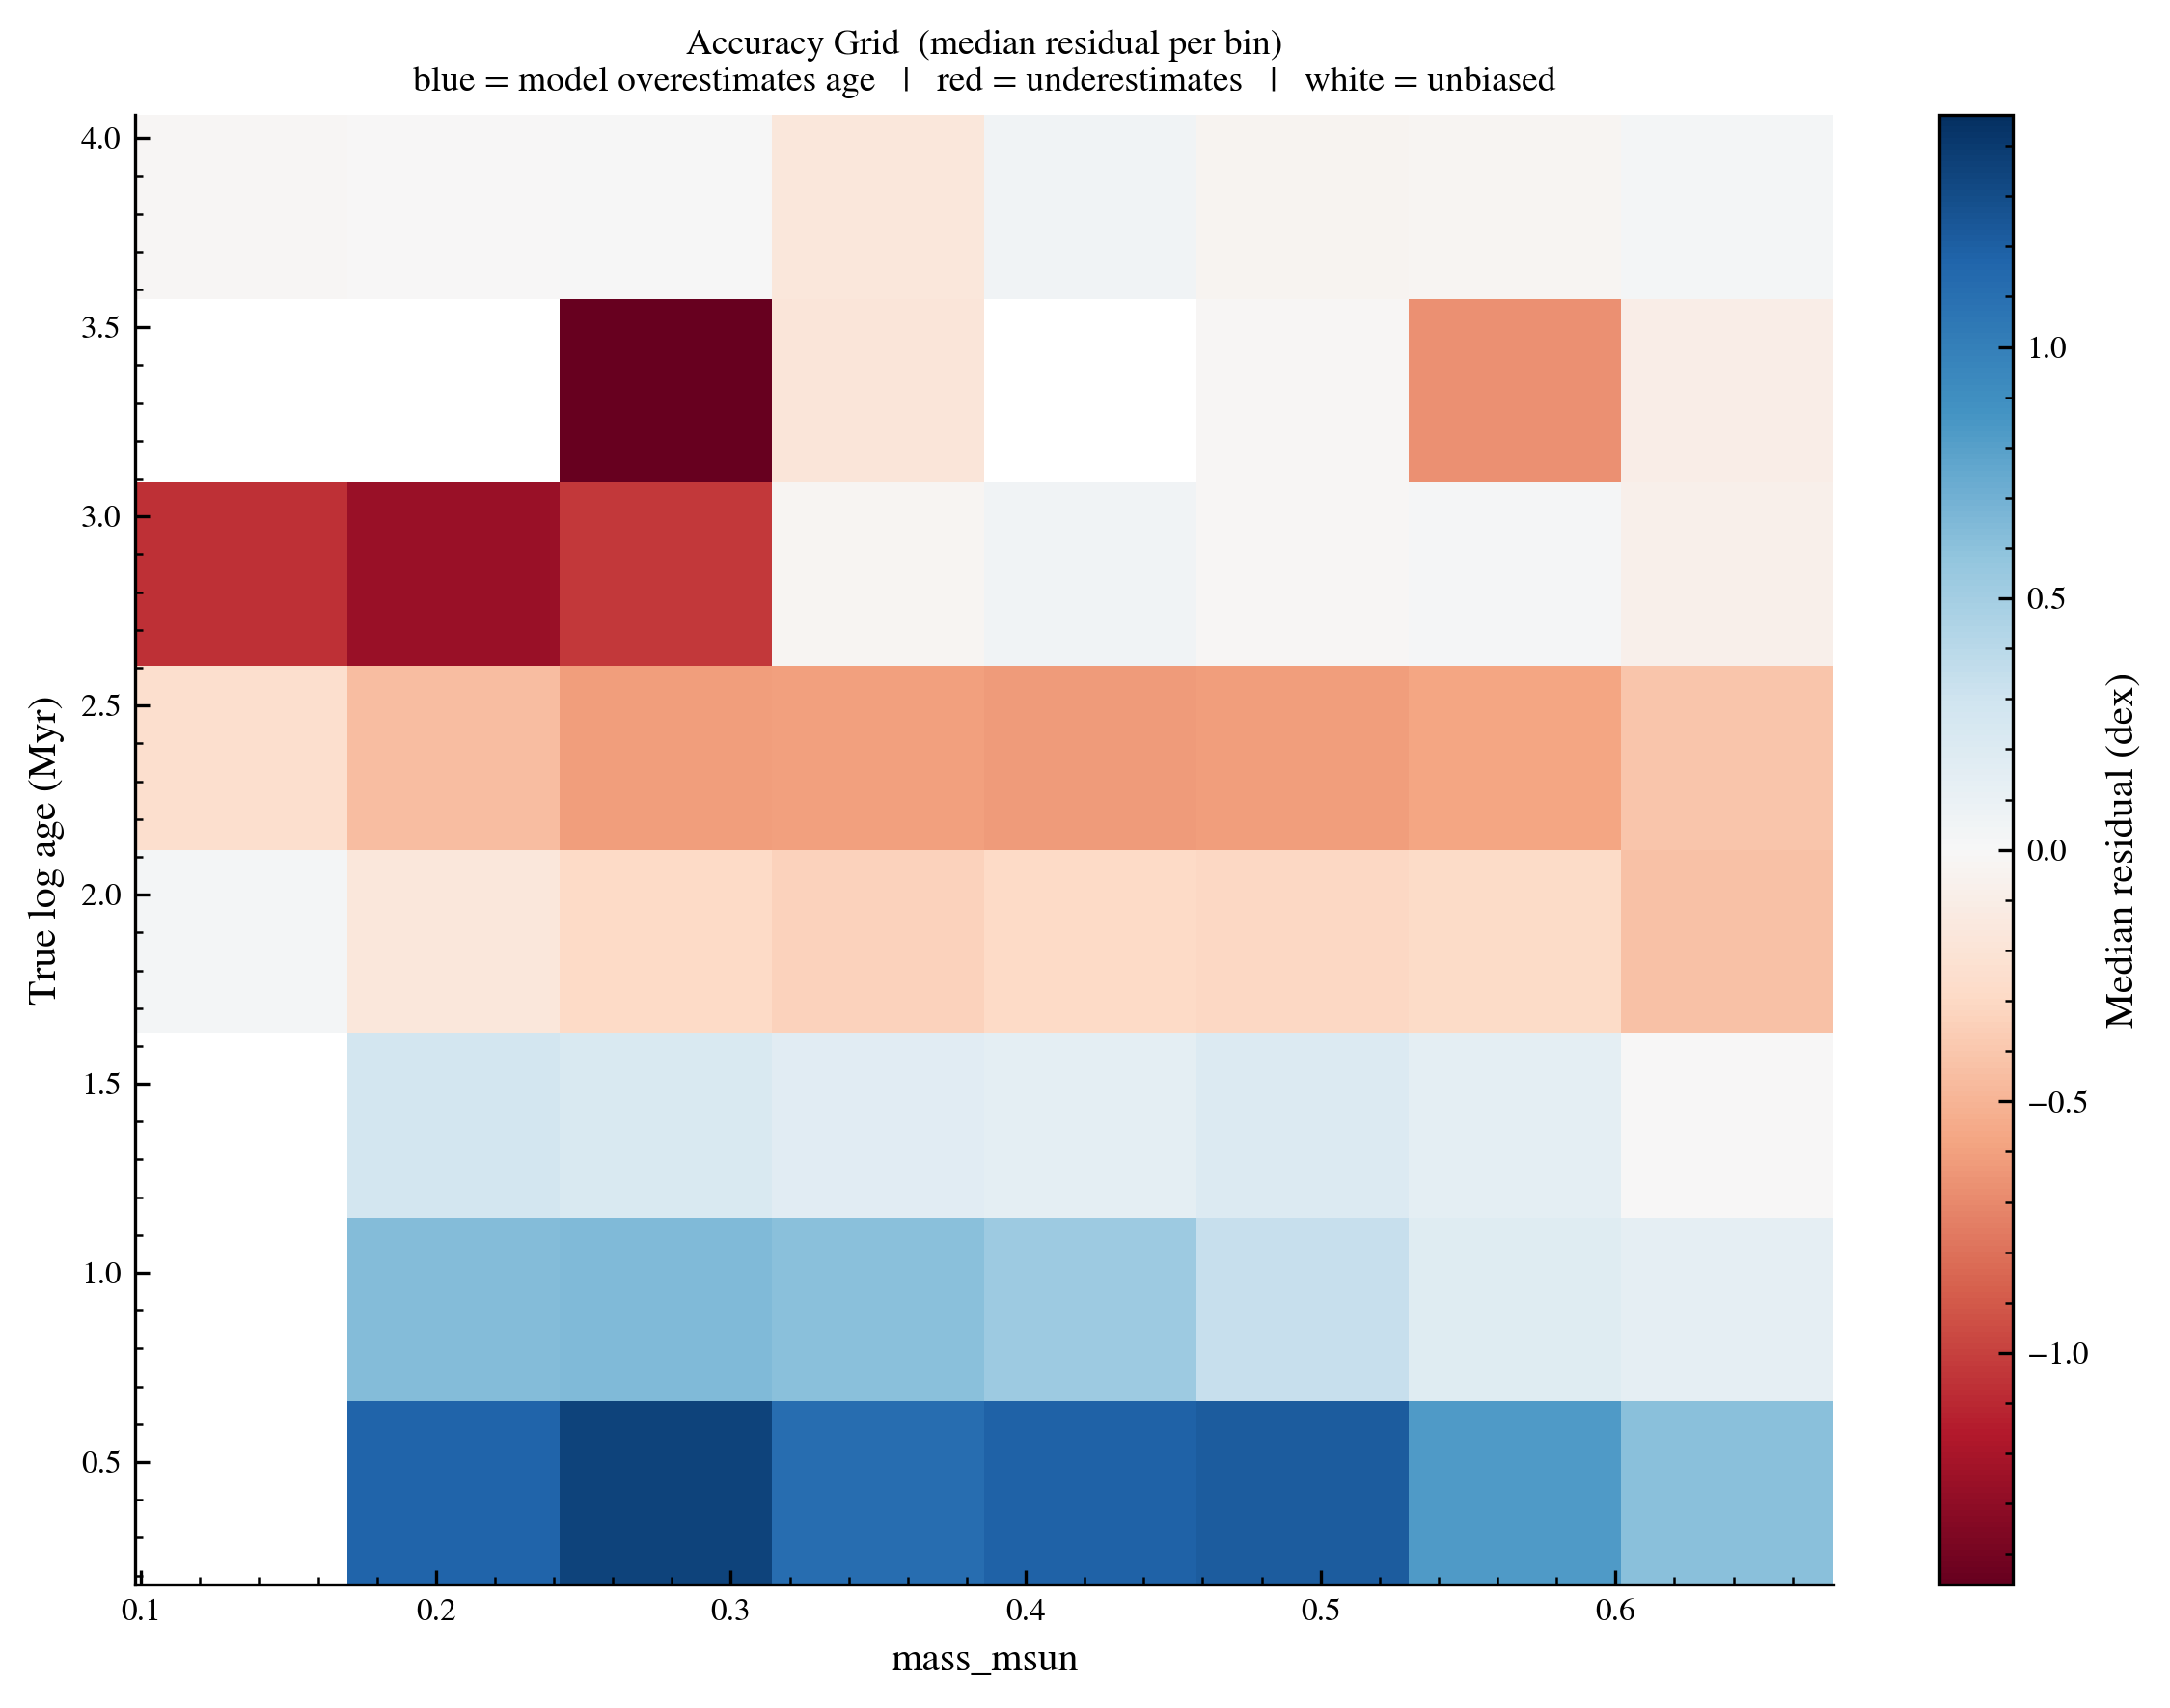

In [6]:
kfold_report(results_df)

## 6. Sample posteriors by age

Posteriors shape: (5515, 1000)


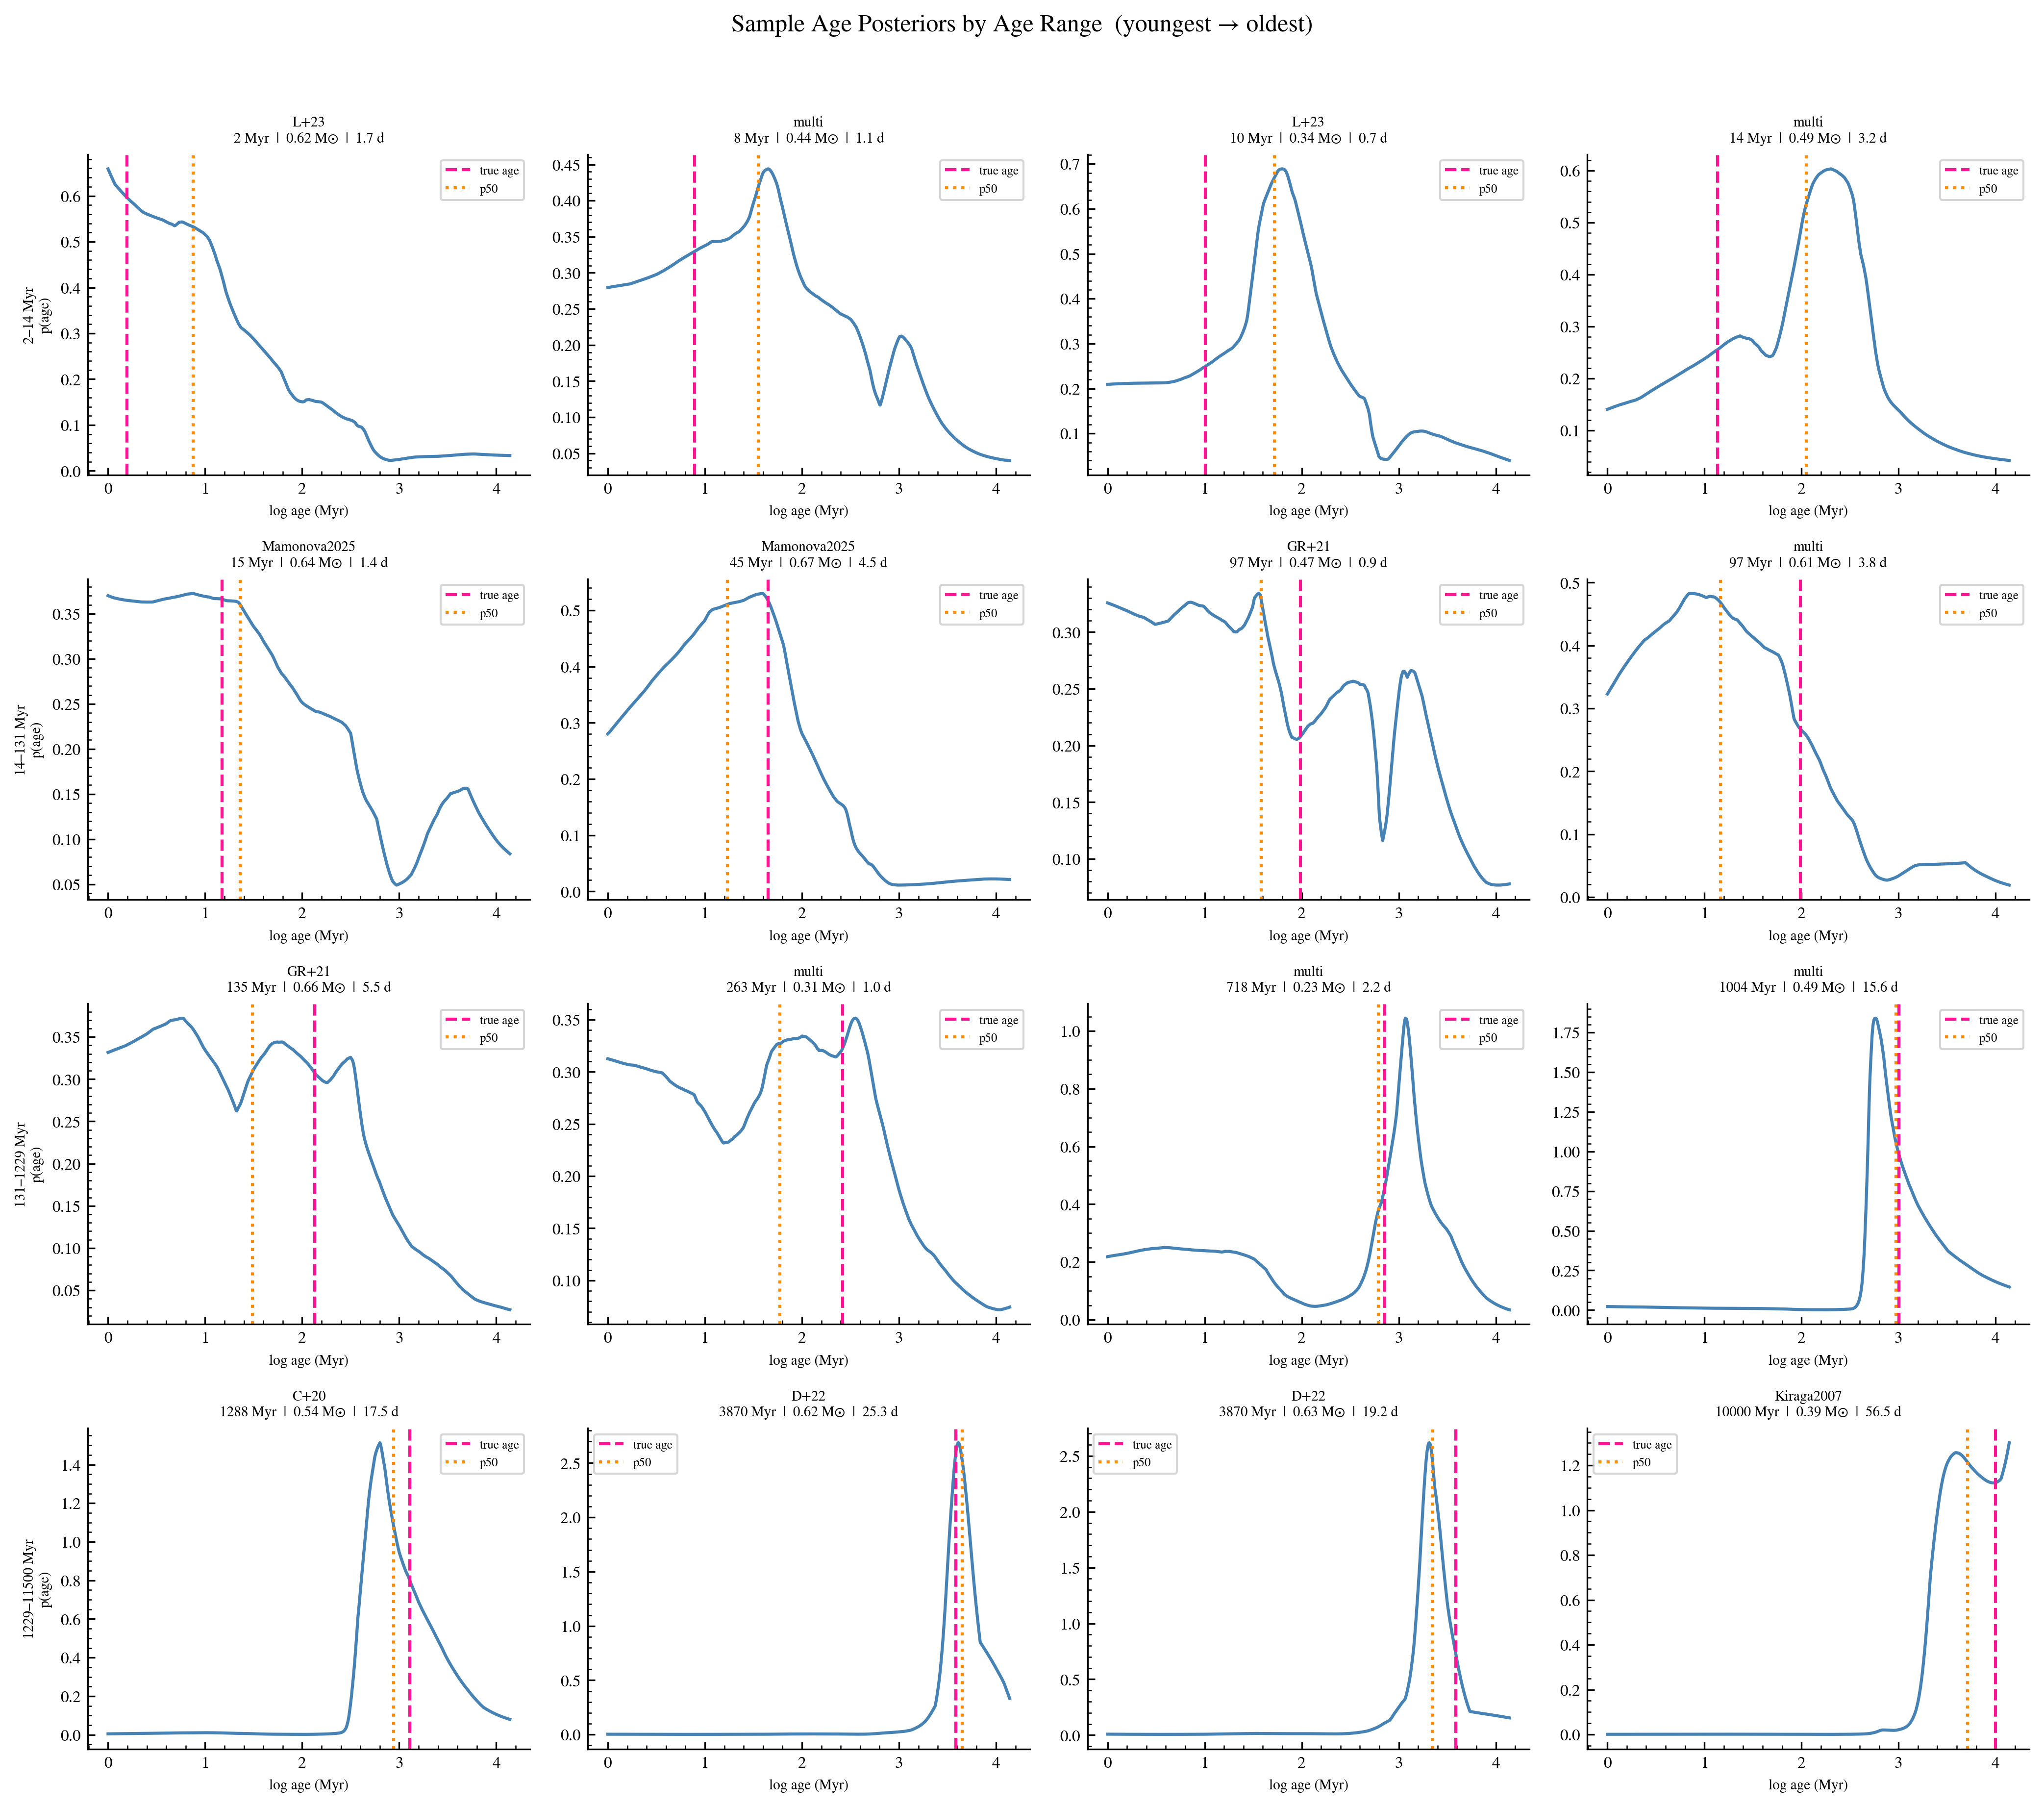

In [7]:
print('Posteriors shape:', posteriors.shape)
plot_posteriors_by_age(posteriors, LOGA_GRID, results_df, n_rows=4, n_cols=4)

## 7. $P(P_\mathrm{rot}\,|\,\mathrm{age,\,mass})$ heatmap per cluster

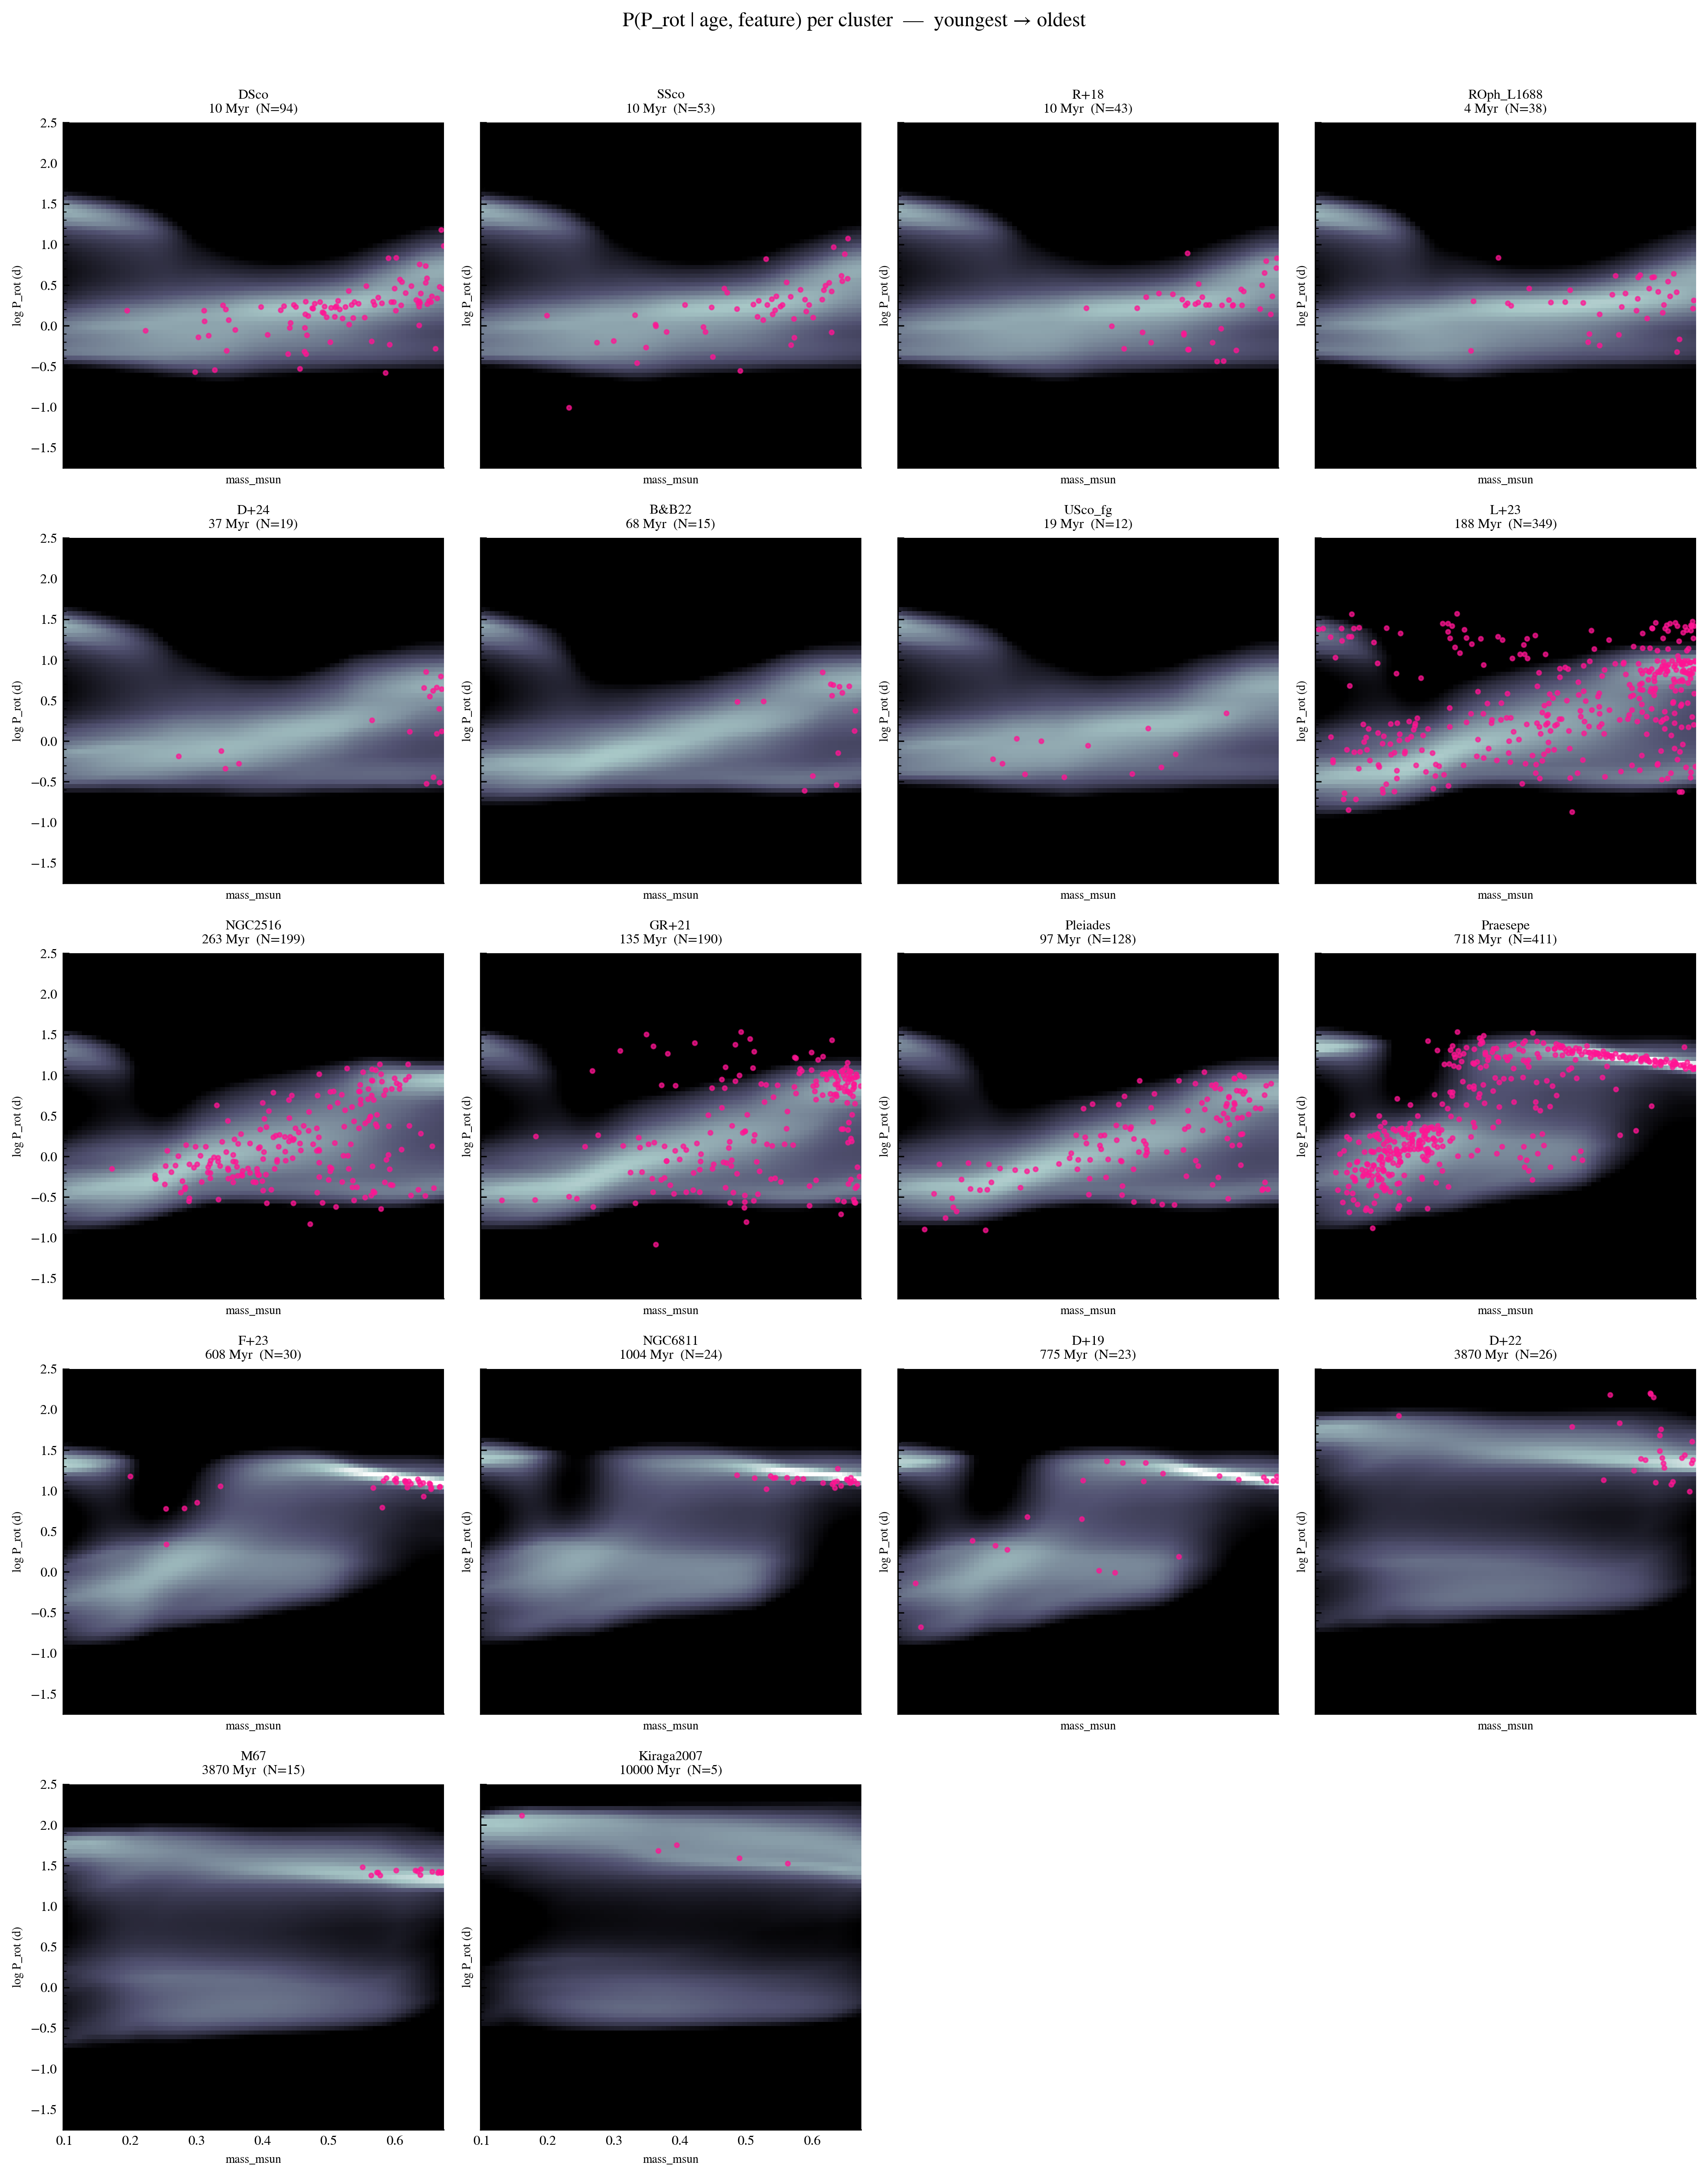

In [8]:
prot_space_report(fold_flows, train_val_df, COND_COLS, fold_scalers)

## 8. Summary statistics

In [9]:
print('=== 2×Layers + OneCycleLR + b=32 — K-fold validation summary ===')
print(f'N stars evaluated : {len(results_df)}')
print(f'Median residual   : {results_df["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(results_df["p84"] - results_df["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(results_df["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
print()
print('Per-fold test log-likelihoods:')
for i, ll in enumerate(test_lls):
    print(f'  Fold {i}: {ll:.6f}')
print(f'  Mean  : {float(np.mean(test_lls)):.6f}')
print()
results_df.groupby('fold')[['residual_dex']].agg(['median', 'std'])

=== 2×Layers + OneCycleLR + b=32 — K-fold validation summary ===
N stars evaluated : 5515
Median residual   : -0.226 dex
Median precision  : 1.906 dex
% within 0.3 dex  : 38.2%

Per-fold test log-likelihoods:
  Fold 0: -0.339447
  Fold 1: -0.325388
  Fold 2: -0.357185
  Fold 3: -0.348187
  Fold 4: -0.340299
  Mean  : -0.342101



residual_dex          
           median       std
fold                       
0       -0.249659  0.657932
1       -0.224072  0.679668
2       -0.206639  0.710265
3       -0.247024  0.690404
4       -0.206564  0.658020

In [10]:
coverage_report(results_df)

=== 68% posterior coverage check ===
N valid stars       : 5515
Observed coverage   : 0.824 (82.4%)
Expected coverage   : 0.680 +/- 0.006 (binomial 1-sigma)
Coverage offset     : +22.89 sigma
Interpretation      : over-covering; posteriors are likely too broad / conservative.


,cover68,n
fold,,
0,0.823209,1103
1,0.817770,1103
2,0.807797,1103
3,0.830462,1103
4,0.839529,1103


## 9. Praesepe density

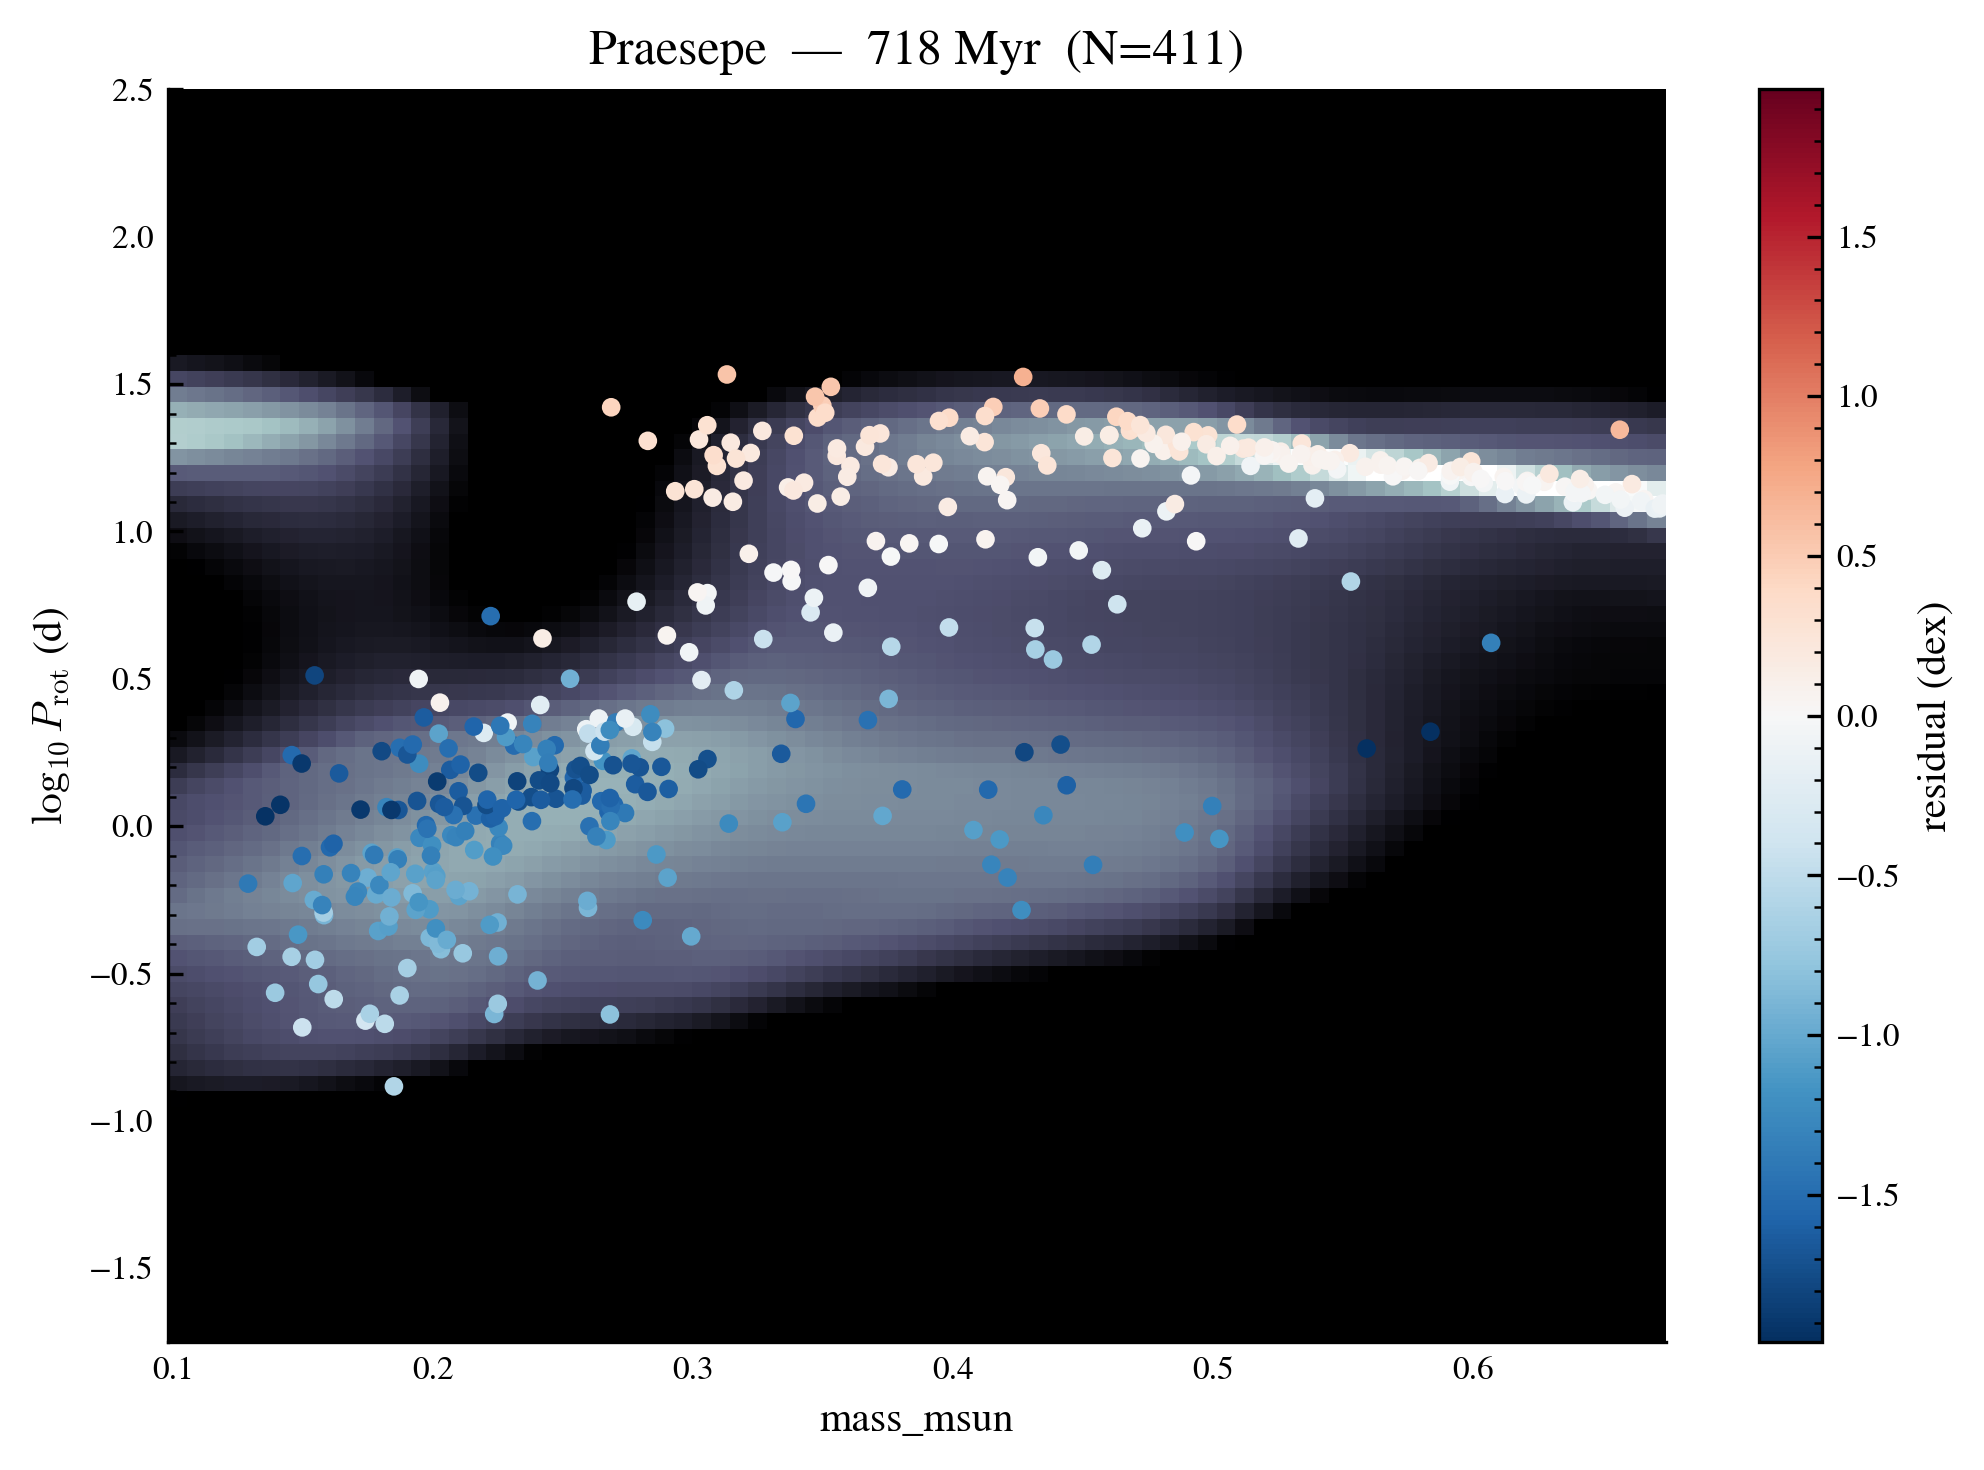

In [11]:
from training.plots import plot_praesepe_density
plot_praesepe_density(fold_flows, train_val_df, results_df, COND_COLS, fold_scalers)

## 10. Fixed-mass $P_\mathrm{rot}$ vs age heatmap

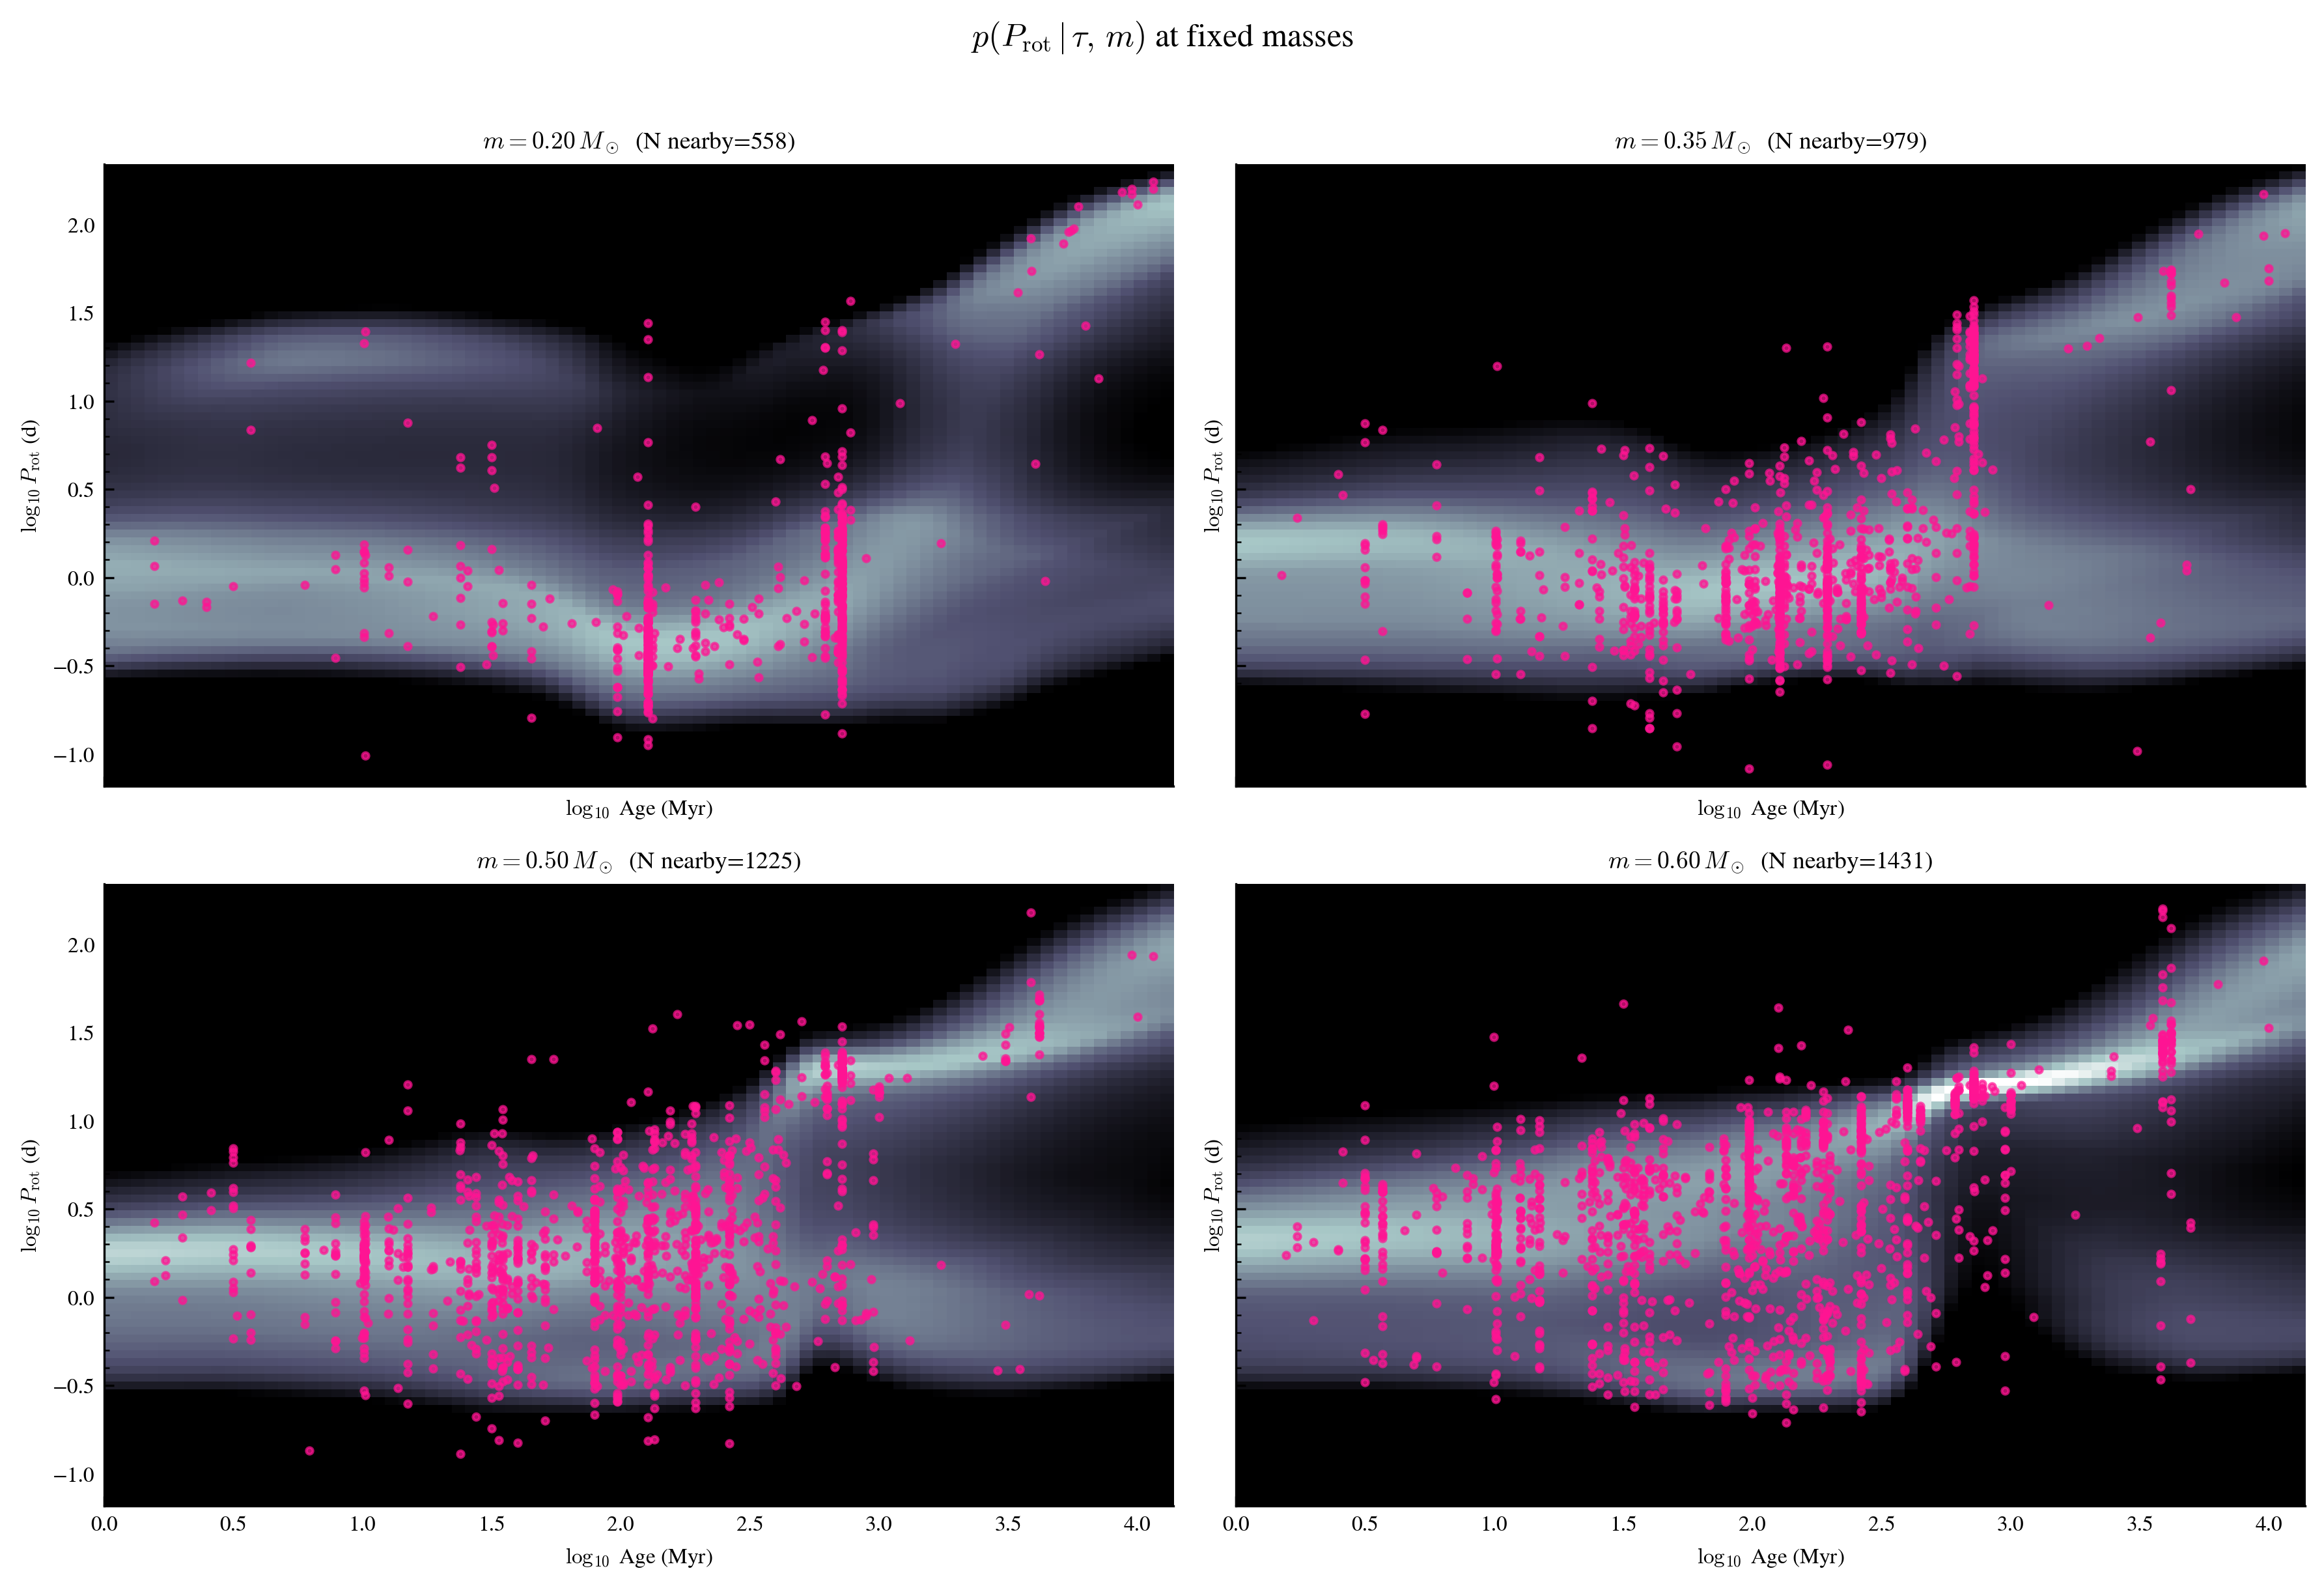

In [12]:
from training.plots import plot_praesepe_density, plot_fixed_mass_heatmap
plot_fixed_mass_heatmap(fold_flows, train_val_df, COND_COLS, fold_scalers,)


## Test set evaluation

Final model trained on the full 90% train/val pool with no early stopping —
hyperparameters were already selected via 5-fold CV above.

In [13]:
from training.data  import make_tensors, make_age_sigma
from training.flow  import create_flow
from training.train import train_fold, compute_test_ll
from training.infer import batch_posteriors
from training.metrics import compute_residuals

print('Training final model on full 90% train/val pool (no early stopping)...')
torch.manual_seed(42)
final_flow = create_flow(n_cond=len(COND_COLS), hidden_features=HIDDEN_FEATURES)

x_all, c_all, final_scaler = make_tensors(train_val_df, OBS_COL, COND_COLS)
log_age_all, sigma_lo_all, sigma_hi_all, has_err_all = make_age_sigma(train_val_df)

train_fold(
    flow         = final_flow,
    x_train      = x_all,
    c_train      = c_all,
    log_age_tr   = log_age_all,
    sigma_lo_tr  = sigma_lo_all,
    sigma_hi_tr  = sigma_hi_all,
    has_err_tr   = has_err_all,
    scaler       = final_scaler,
    total_steps  = TOTAL_STEPS,
    batch_size   = BATCH_SIZE,
    n_samples    = N_SAMPLES,
    use_onecycle = True,
    early_stop   = False,
)

x_test_t, c_test_t, _ = make_tensors(test_df, OBS_COL, COND_COLS, final_scaler)
final_test_ll = compute_test_ll(final_flow, x_test_t, c_test_t)
print(f'Final model test avg log-likelihood: {final_test_ll:.6f}')

test_posts   = batch_posteriors(final_flow, test_df, OBS_COL, COND_COLS, final_scaler)
test_results = compute_residuals(test_df, test_posts)
print(f'Test stars: {len(test_results)}')

Training final model on full 90% train/val pool (no early stopping)...
  total_steps=10000  steps_per_epoch=173  epochs=57
Final model test avg log-likelihood: -0.348094
Test stars: 613


In [14]:
print('=== Test set summary ===')
print(f'N stars           : {len(test_results)}')
print(f'Median residual   : {test_results["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(test_results["p84"] - test_results["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(test_results["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
print(f'Final model test LL: {final_test_ll:.6f}')

=== Test set summary ===
N stars           : 613
Median residual   : -0.219 dex
Median precision  : 1.887 dex
% within 0.3 dex  : 40.8%
Final model test LL: -0.348094


In [15]:
coverage_report(test_results)

=== 68% posterior coverage check ===
N valid stars       : 613
Observed coverage   : 0.834 (83.4%)
Expected coverage   : 0.680 +/- 0.019 (binomial 1-sigma)
Coverage offset     : +8.15 sigma
Interpretation      : over-covering; posteriors are likely too broad / conservative.


/Users/alanxia/Documents/GitHub/cf_xmatch/training/notebooks/../../training/plots.py:287: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.scatter(xvals, resid, **_kw_scat)


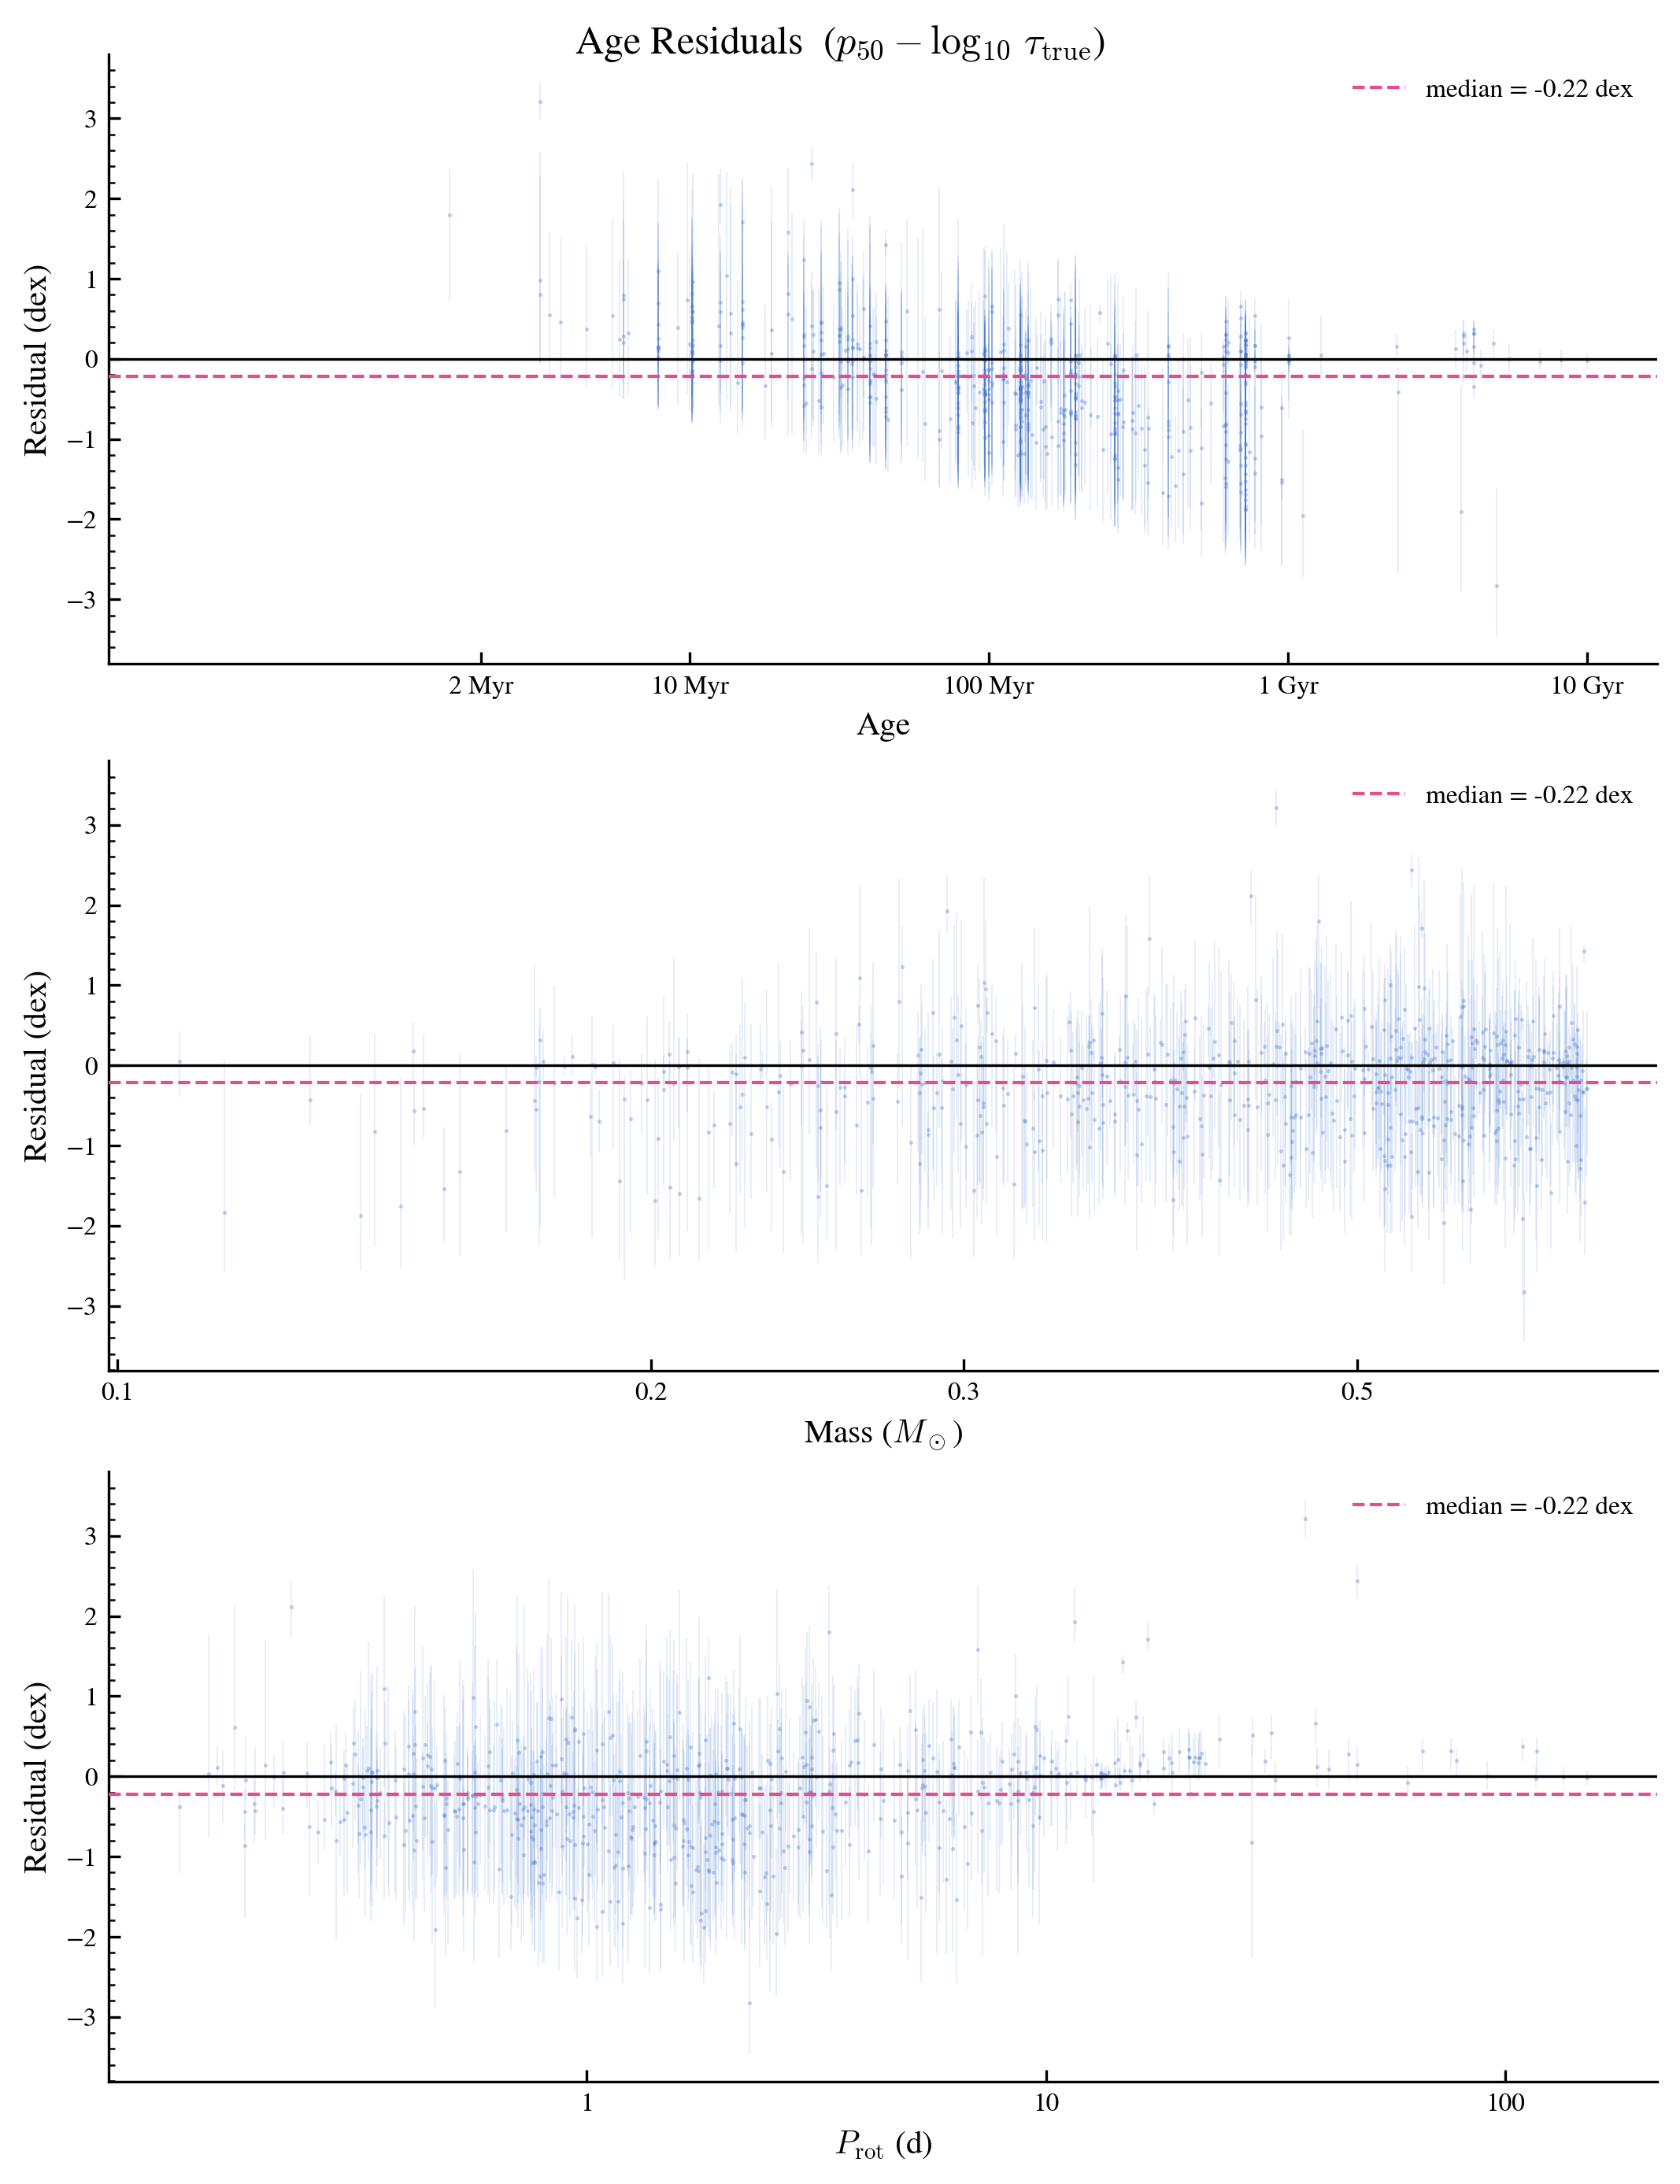

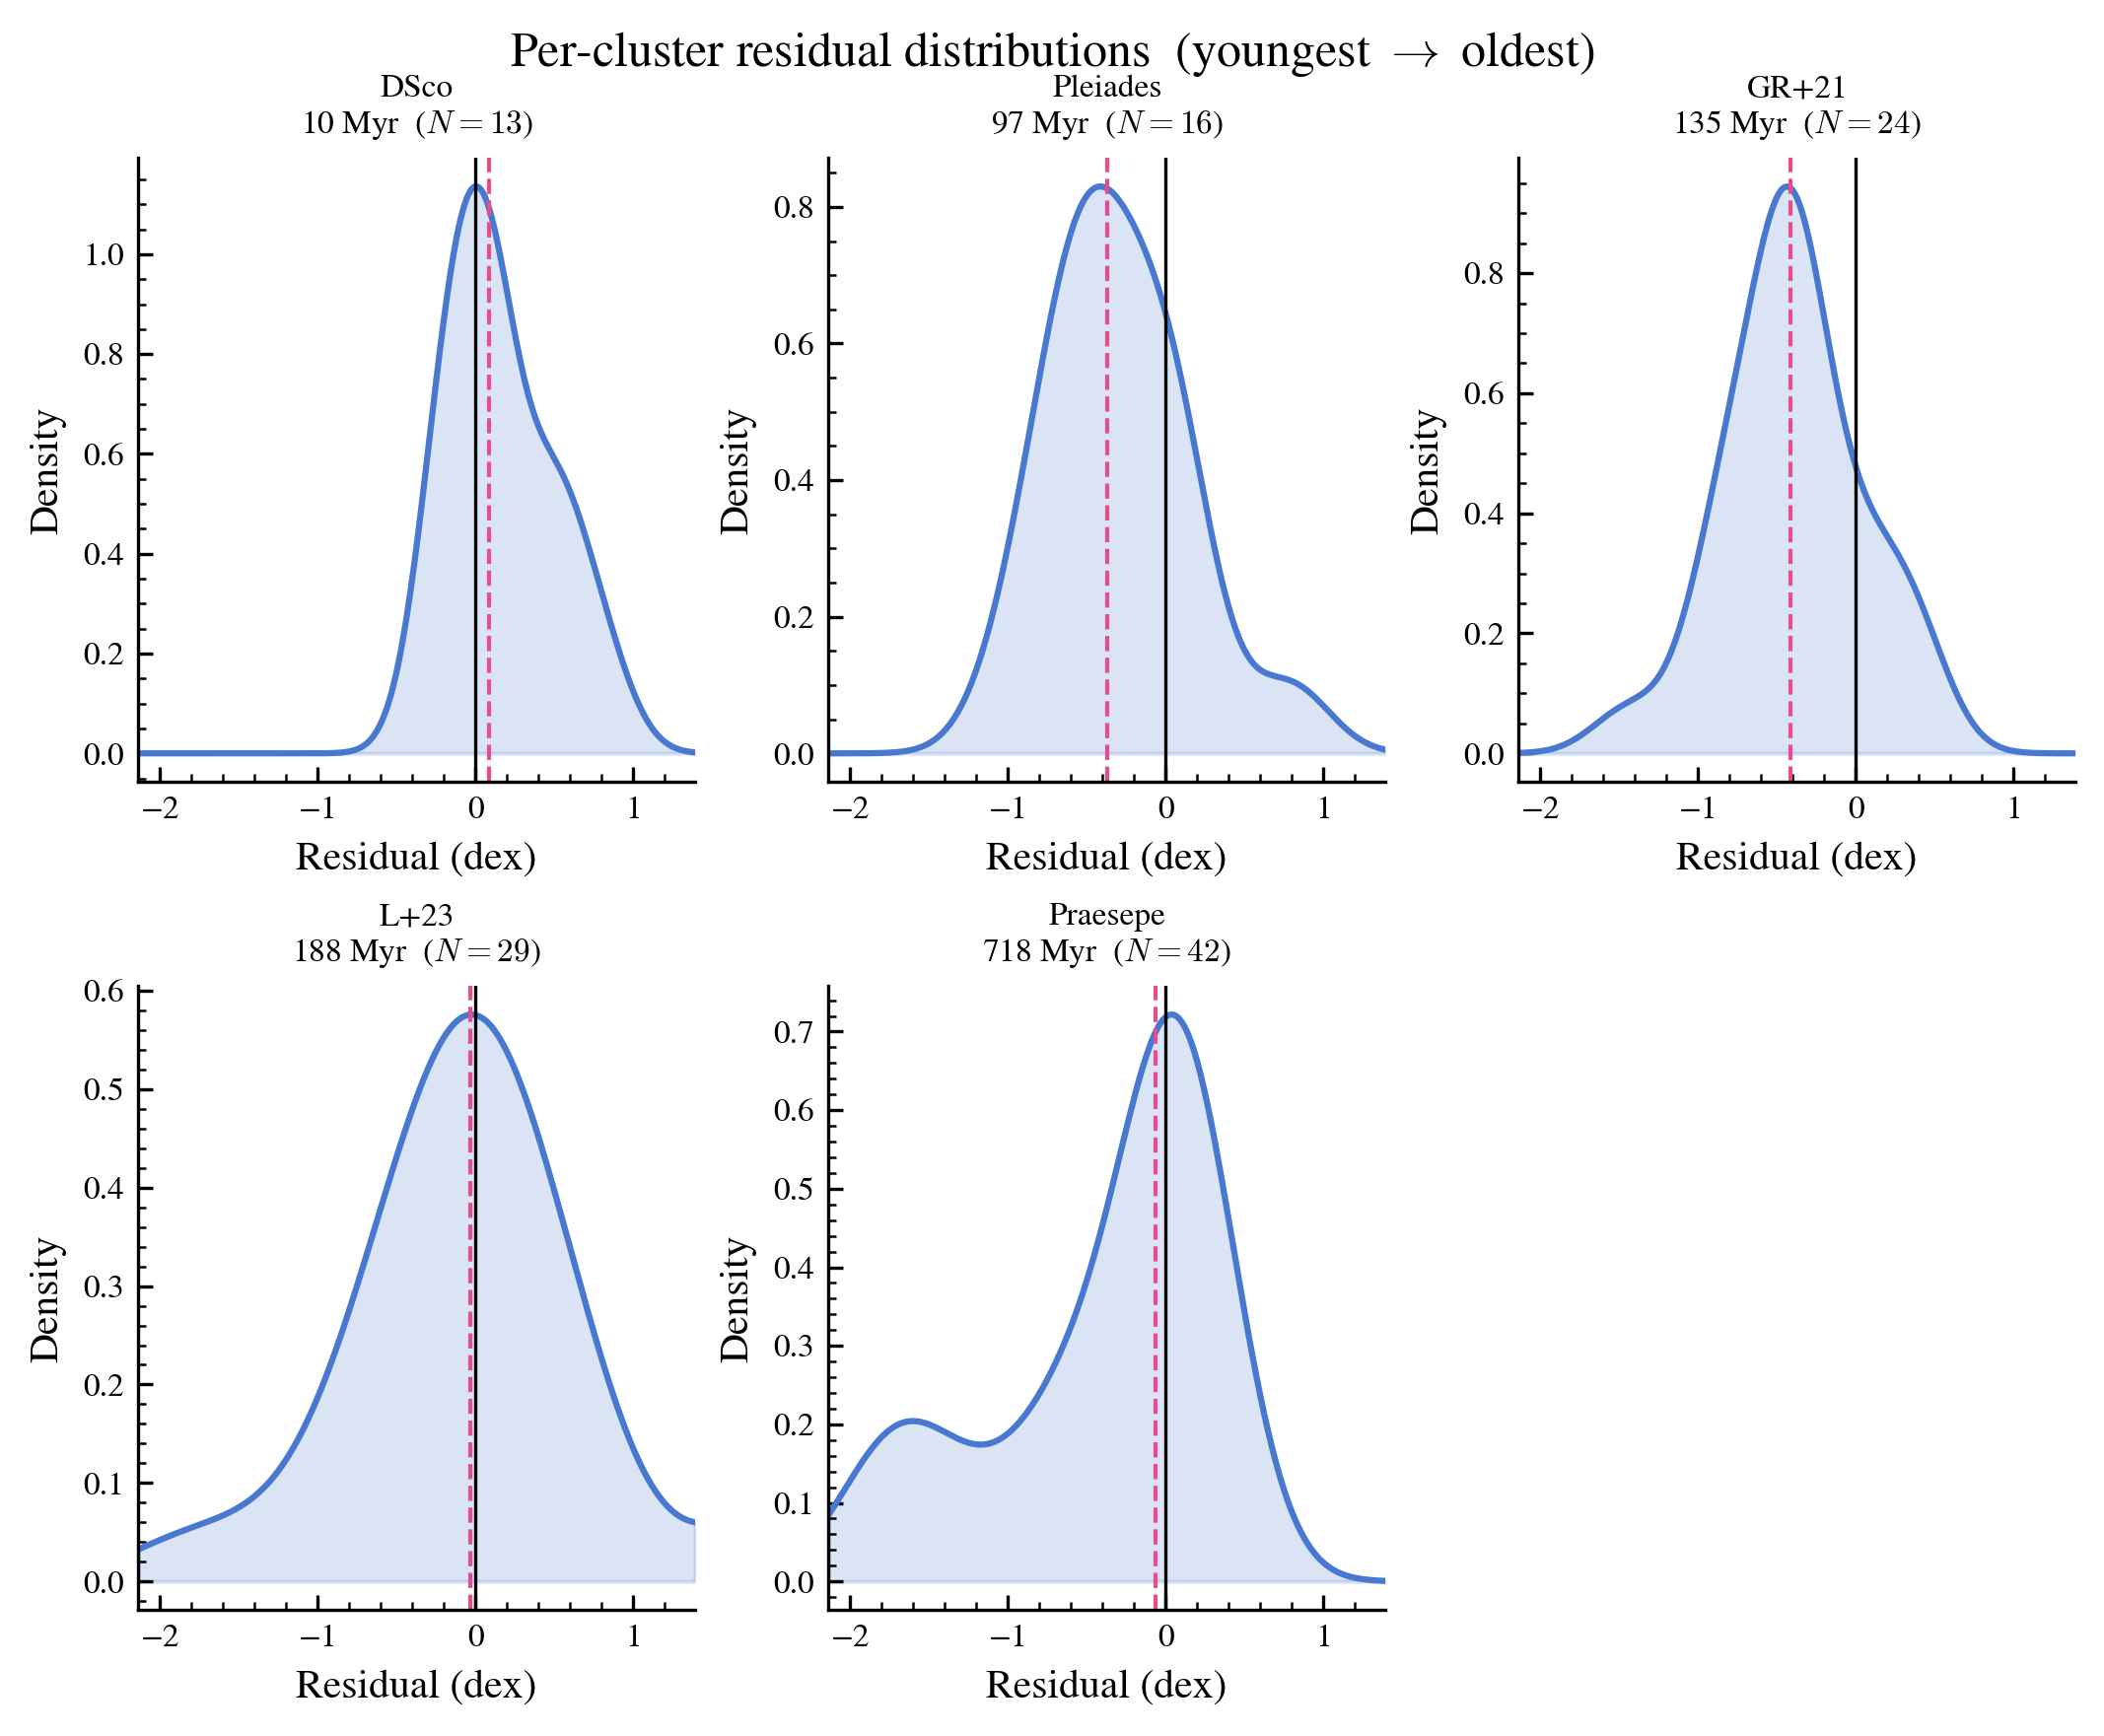

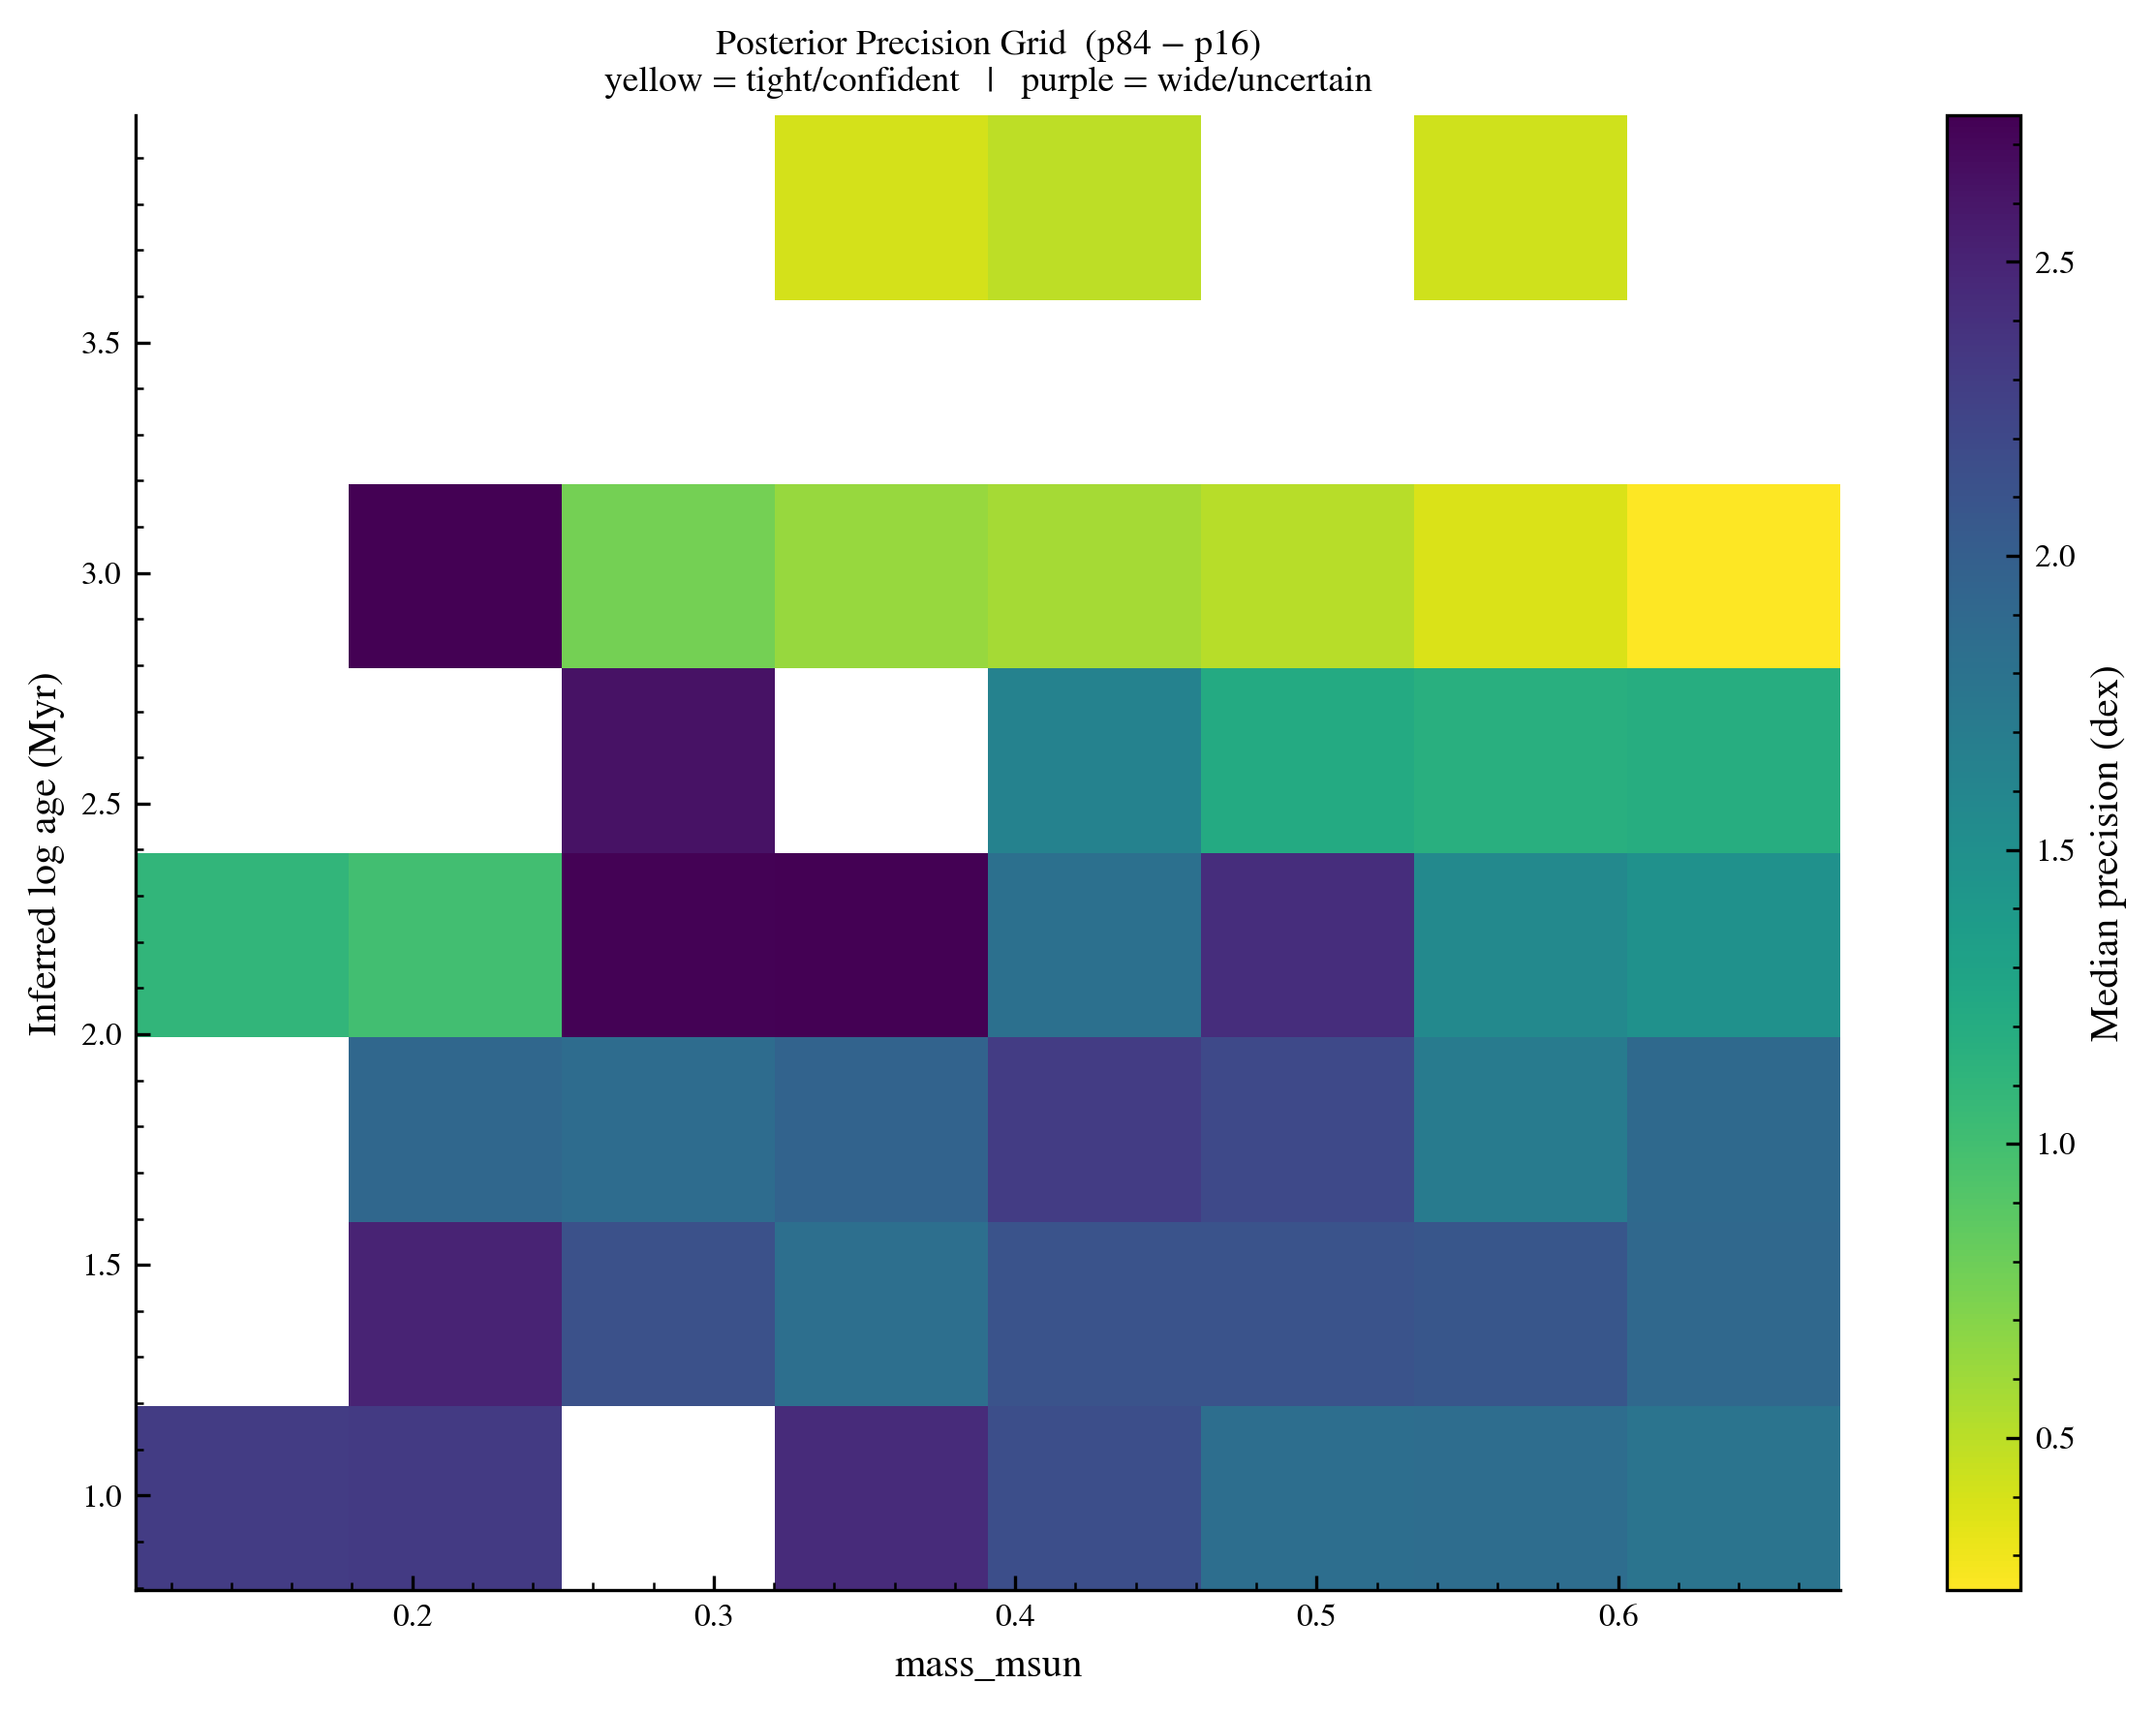

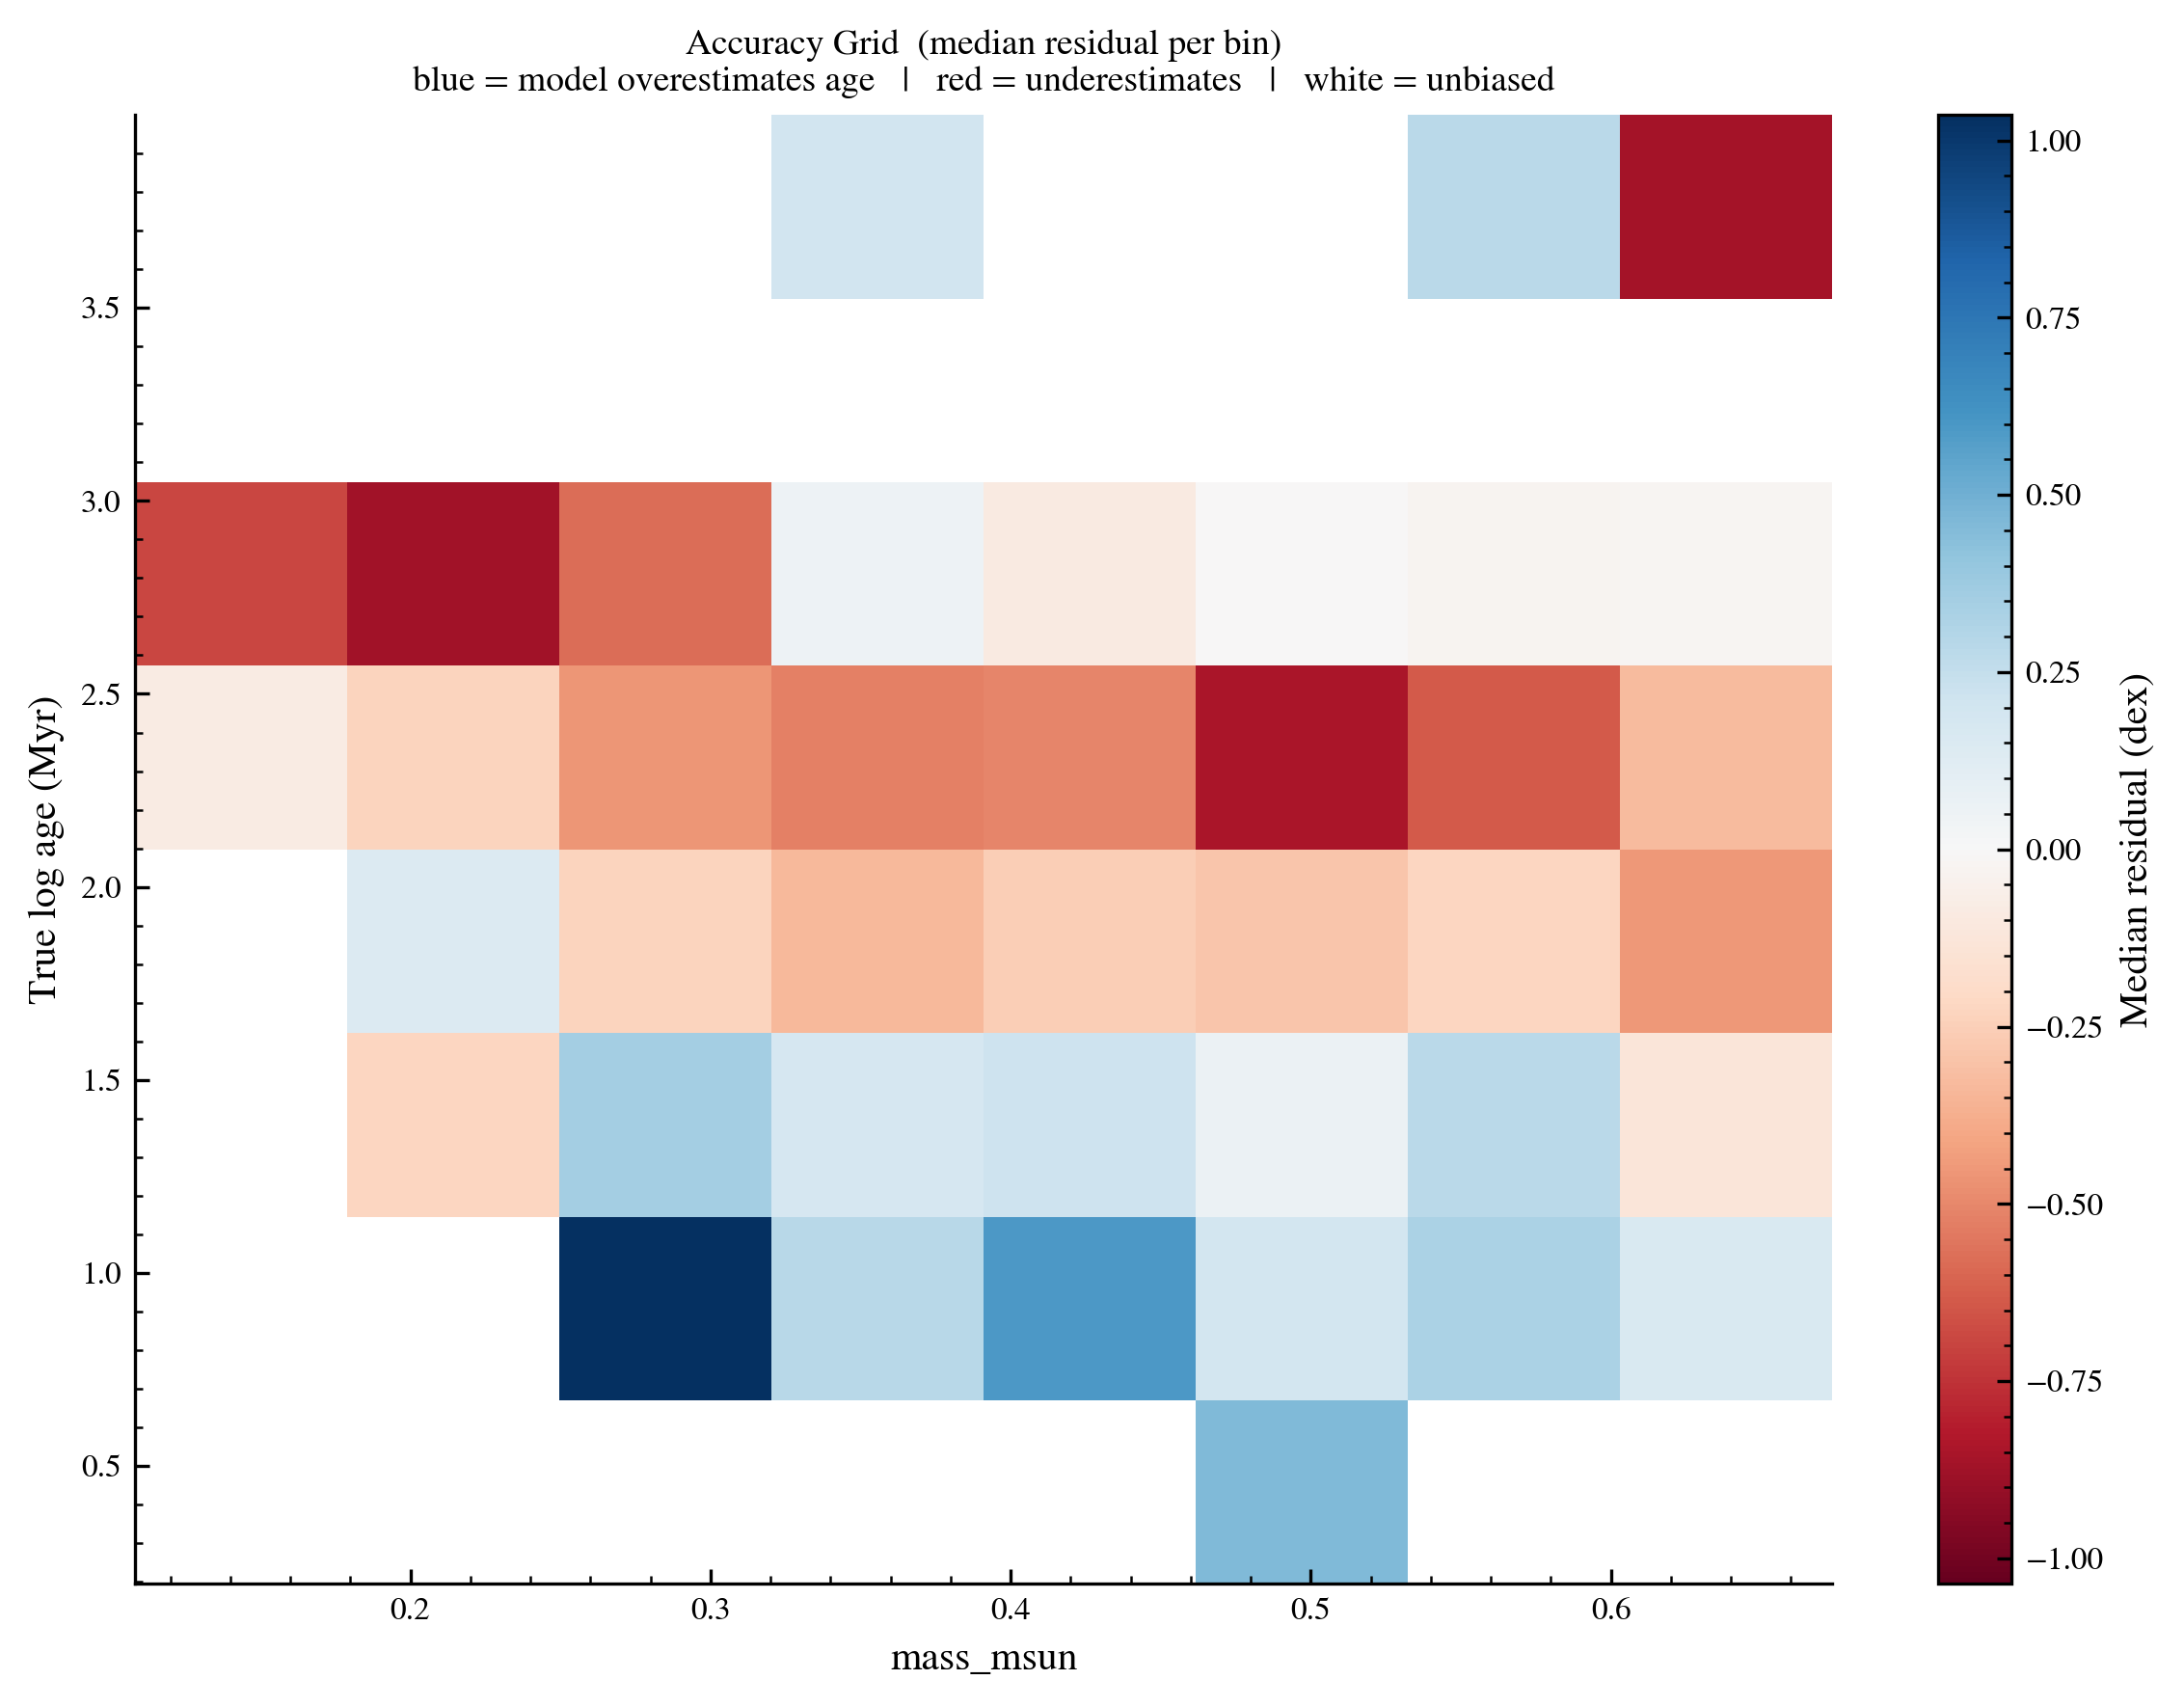

In [16]:
kfold_report(test_results)

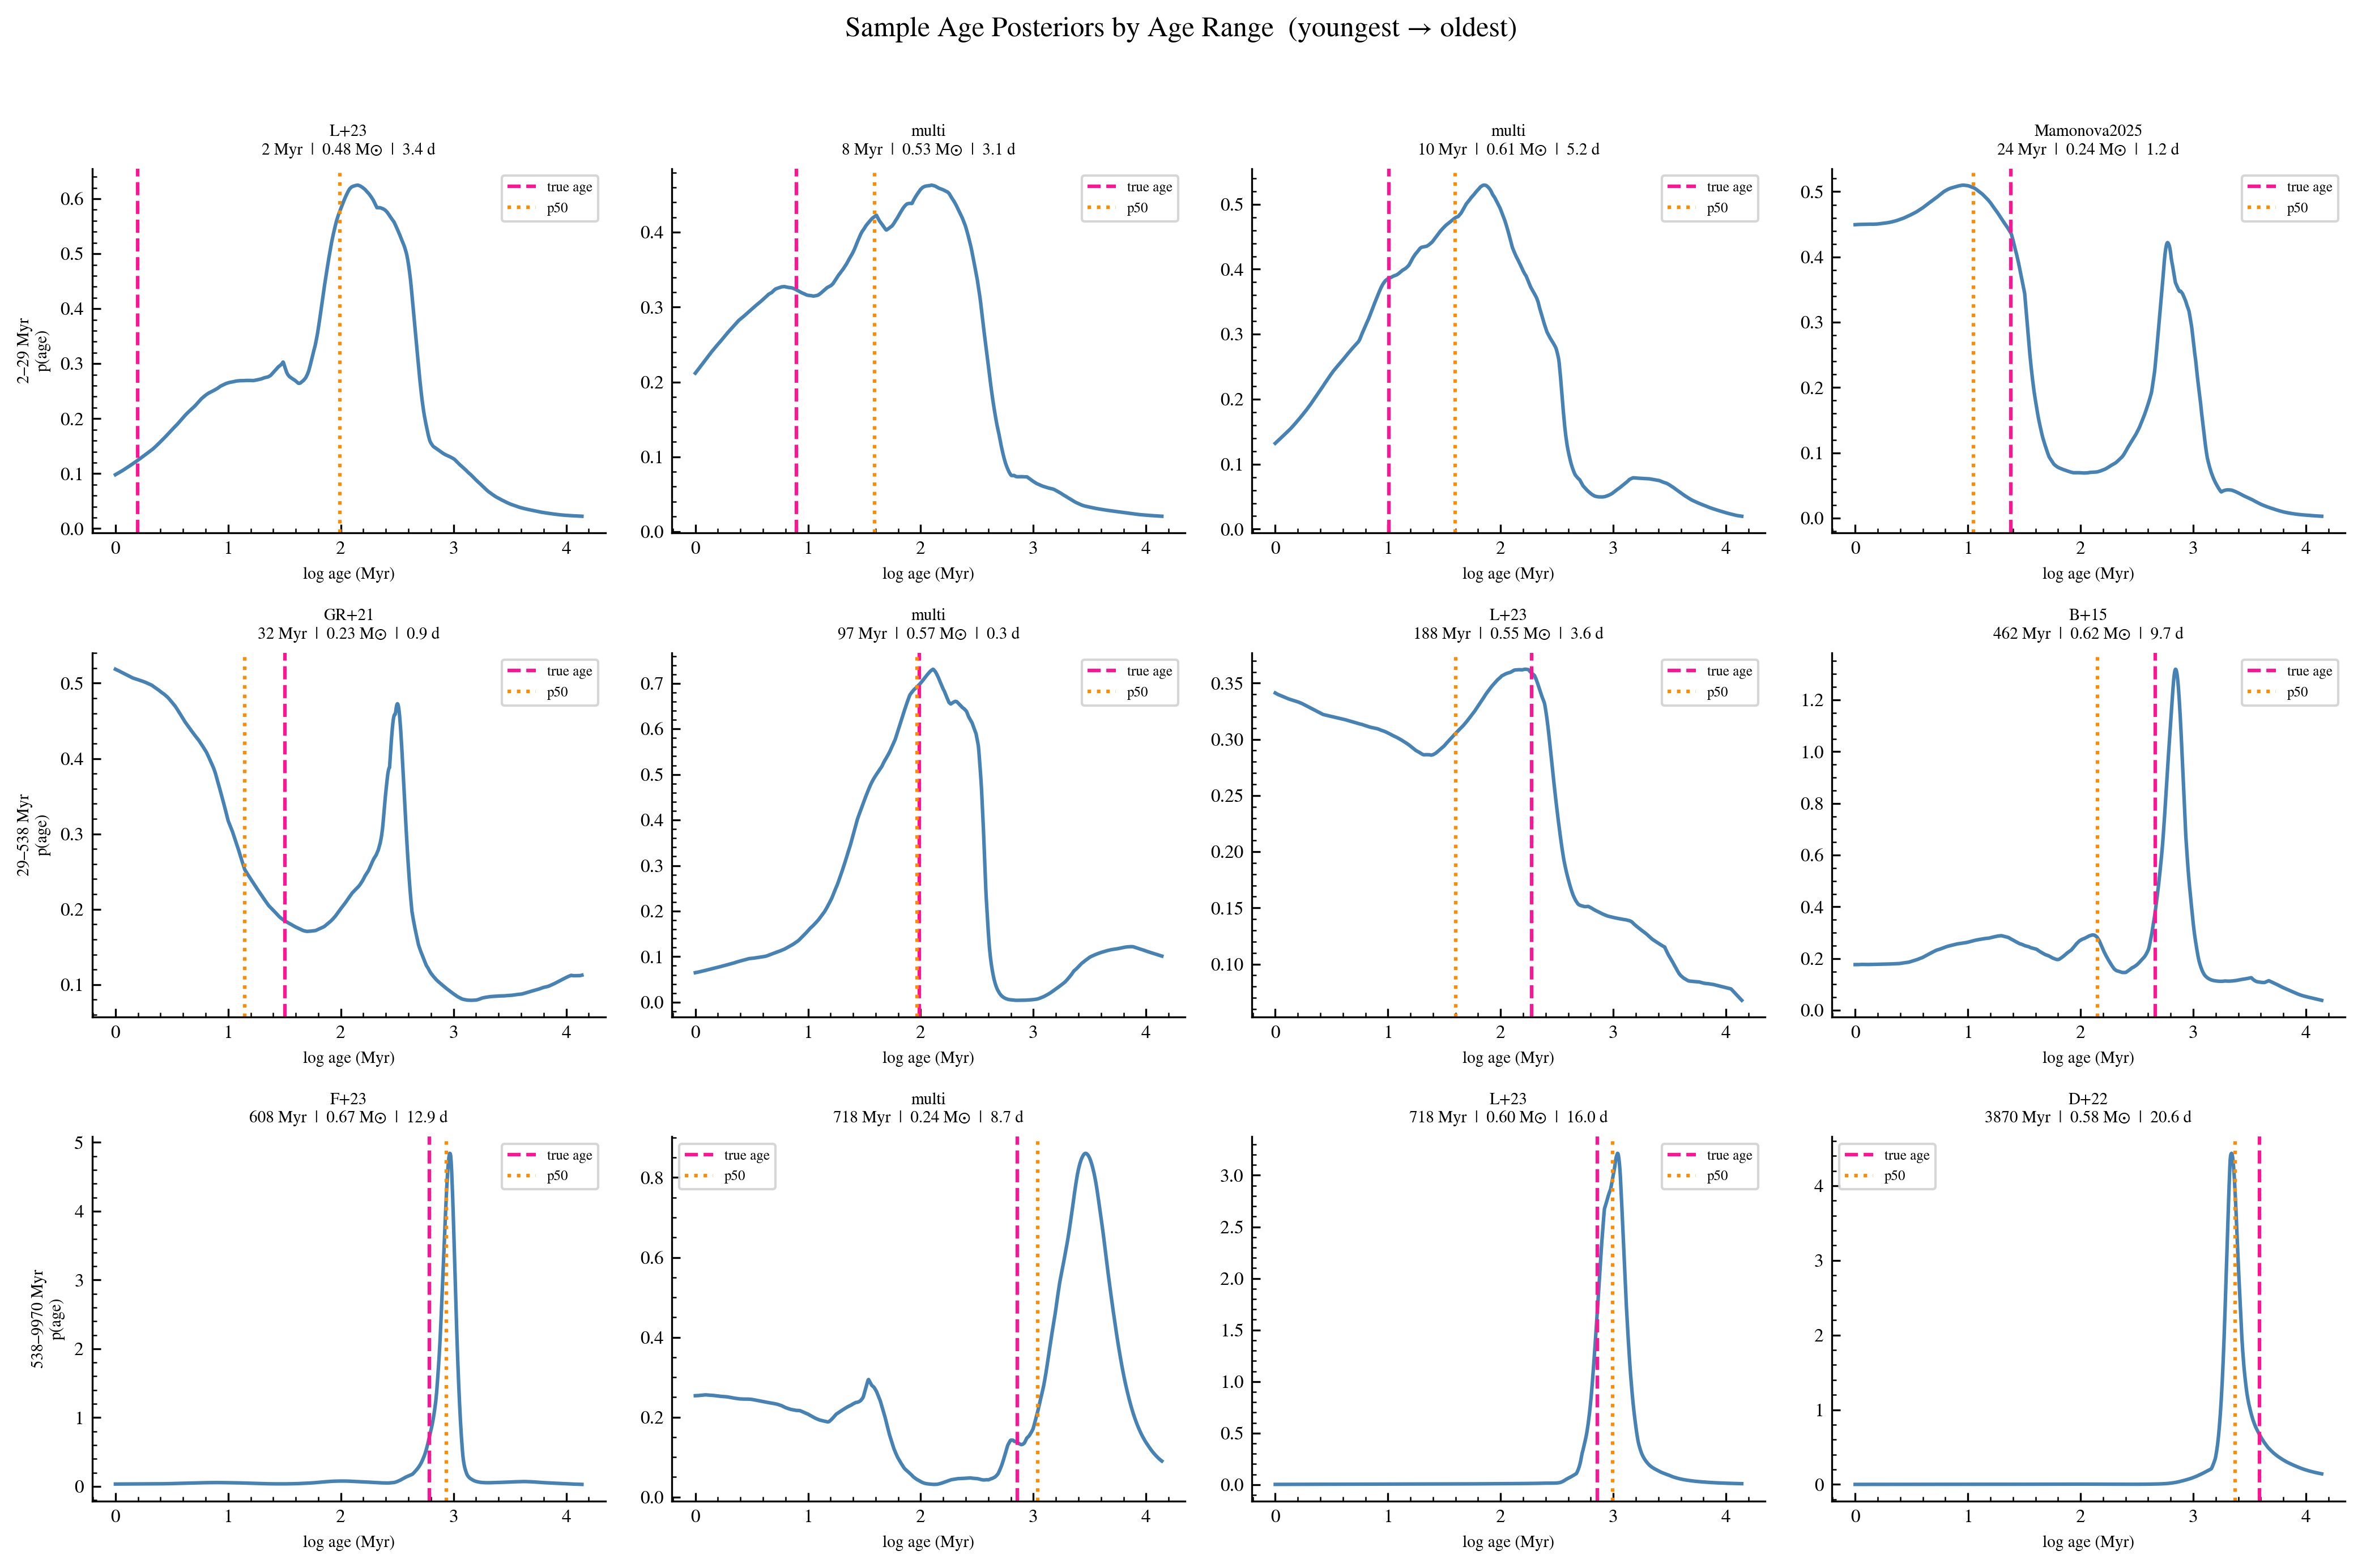

In [17]:
plot_posteriors_by_age(test_posts, LOGA_GRID, test_results, n_rows=3, n_cols=4)

## 11. Save

In [18]:
import os
out_dir = '../../outputs/mass_model/2xlayers_b32'
os.makedirs(out_dir, exist_ok=True)

results_df.to_csv(f'{out_dir}/results.csv', index=False)
np.save(f'{out_dir}/posteriors_kfold.npy', posteriors)
np.save(f'{out_dir}/train_curves.npy', np.array(train_curves, dtype=object), allow_pickle=True)
np.save(f'{out_dir}/val_curves.npy',   np.array(val_curves,   dtype=object), allow_pickle=True)
np.save(f'{out_dir}/test_lls.npy',     np.array(test_lls))

for i, (flow, scaler) in enumerate(zip(fold_flows, fold_scalers)):
    torch.save(flow.state_dict(), f'{out_dir}/fold{i}_flow.pt')
    with open(f'{out_dir}/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print(f'Saved to {out_dir}/')

Saved to ../../outputs/mass_model/2xlayers_b32/
